# K Nearest Neighbours (XAI Analysis)


**Project:** Pokémon Type Prediction from Sprite Colors (XAI)

**Team:** Grifo Amarillo

**Model:** KNN 

**Task:** Predict Pokémon primary type from sprite color features (17 classes, 42 features)

In [194]:
import json, random, sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
import shap
import lime
import lime.lime_tabular
from functools import partial
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

cwd = Path.cwd()
if (cwd / "src").is_dir():
    src_path = cwd / "src"
elif (cwd.parent / "src").is_dir():
    src_path = cwd.parent / "src"
else:
    raise FileNotFoundError("Could not find the 'src' directory. Check your working directory.")

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import common

plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid")

## 1. Data loading and preparation

We start by loading the data and doing a train/test split based on the `common.py` module.

In [195]:
df = common.load_data()
type_to_int, int_to_type = common.get_label_mapping()
feature_cols = common.FEATURE_COLS_ALL

X_train, X_test, y_train, y_test, split_idx = common.get_train_test_split(df)
scaler = common.get_scaler(X_train)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 820 | Test: 205


KNN is a distance-based method. A scaler is essential to prevent high-variance features from dominating the distances.

### 1.1. Training set class distribution

Before fitting the KNN model we inspect the distribution of primary types in the training set. Understanding class imbalance upfront helps us anticipate where the model will over and under-predict, and sets the context for why `f1-macro` is the right scoring metric here.

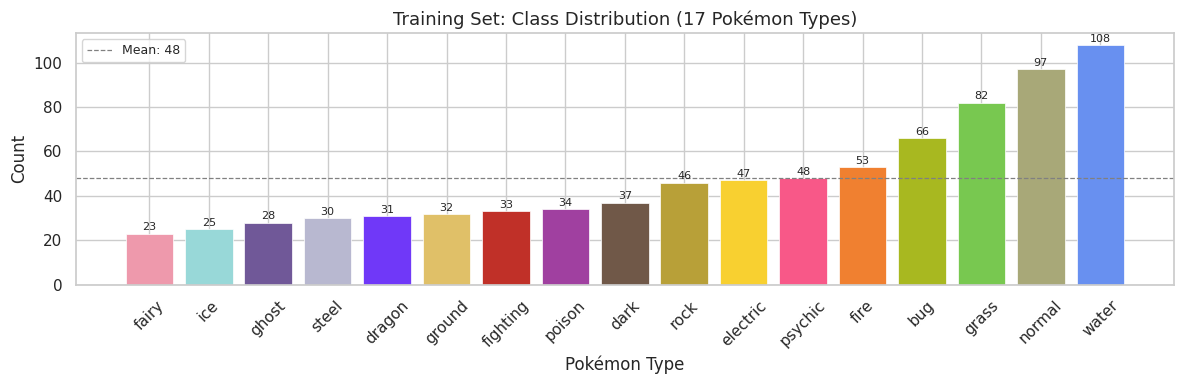

Largest class:        water  (108 samples)
Smallest class:       fairy  (23 samples)
Imbalance ratio: 4.7x

Classes below mean (48 samples):
type1_encoded
fairy       23
ice         25
ghost       28
steel       30
dragon      31
ground      32
fighting    33
poison      34
dark        37
rock        46
electric    47
psychic     48


In [196]:
dist_train = y_train.map(int_to_type).value_counts().sort_values()
colors_train = [common.TYPE_COLORS.get(t, "#888888") for t in dist_train.index]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(dist_train.index, dist_train.values, color=colors_train, edgecolor="white", linewidth=0.5)
mean_count = dist_train.mean()
ax.axhline(mean_count, color="gray", linestyle="--", linewidth=0.9, label=f"Mean: {mean_count:.0f}")
ax.set_title("Training Set: Class Distribution (17 Pokémon Types)", fontsize=13)
ax.set_xlabel("Pokémon Type")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
for bar, val in zip(bars, dist_train.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(val), ha="center", va="bottom", fontsize=8)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Largest class:   {dist_train.idxmax():>10}  ({dist_train.max()} samples)")
print(f"Smallest class:  {dist_train.idxmin():>10}  ({dist_train.min()} samples)")
print(f"Imbalance ratio: {dist_train.max() / dist_train.min():.1f}x")
print(f"\nClasses below mean ({mean_count:.0f} samples):")
print(dist_train[dist_train < mean_count].sort_values().to_string())

The training set has representation of the 17 classes with a maximum imbalance ratio of roughly 4.7 (`water` 108 samples vs `fairy` 23). This matters directly for KNN: if most training points belong to Water or Normal, then for any query point these types will tend to dominate its neighborhood purely by density, even if the query's color profile is not especially "Water-like". Unlike a Decision Tree (which accepts `class_weight="balanced"`), KNN has no native counterweight. The grid search selects weights="distance" as the only built-in mitigation, giving closer neighbors a larger vote share.

## 2. Training

### 2.1. Gridsearch

We perform a gridsearch to select the best KNN variant for this problem. Since there is high correlation between variables, we introduce the number of selected features as a hyperparameter.

In [197]:
seeded_classifier = partial(mutual_info_classif, random_state=42)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectKBest(score_func=seeded_classifier)),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    "feature_selection__k": [10, 15, 20, 25, 30, 42],
    "knn__n_neighbors": [3, 5, 7, 9, 13],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan", "chebyshev"] 
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=cv, 
    scoring="f1_macro", 
    n_jobs=-1, 
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\n--- Final Results ---")
print(f"Best CV f1_macro: {grid_search.best_score_:.4f}")
print(f"Best KNN params: {grid_search.best_params_}")
print(f"Best feature count: {len(grid_search.best_estimator_.named_steps['feature_selection'].get_support(indices=True))}")
print(f"Best feature indices: {grid_search.best_estimator_.named_steps['feature_selection'].get_support(indices=True)}")

if hasattr(X_train, "columns"):
    best_columns = X_train.columns[grid_search.best_estimator_.named_steps['feature_selection'].get_support(indices=True)].tolist()
    print(f"Best feature names: {best_columns}")

Fitting 5 folds for each of 180 candidates, totalling 900 fits

--- Final Results ---
Best CV f1_macro: 0.2334
Best KNN params: {'feature_selection__k': 20, 'knn__metric': 'manhattan', 'knn__n_neighbors': 9, 'knn__weights': 'distance'}
Best feature count: 20
Best feature indices: [ 0  1  2  4  5  8  9 20 21 22 23 26 28 30 31 33 35 37 38 40]
Best feature names: ['dom1_h', 'dom1_s', 'dom1_v', 'dom2_h', 'dom2_s', 'dom3_h', 'dom3_s', 'mean_h_sin', 'mean_h_cos', 'mean_s', 'mean_v', 'std_hue_angular', 'prop_saturated', 'hue_bin_0', 'hue_bin_30', 'hue_bin_90', 'hue_bin_150', 'hue_bin_210', 'hue_bin_240', 'hue_bin_300']


We finally obtain a f1_macro of 0.2334 in validation. Notice that we just use 20 of the 42 parameters.

              precision    recall  f1-score   support

         bug       0.14      0.12      0.13        17
        dark       0.00      0.00      0.00         9
      dragon       0.20      0.12      0.15         8
    electric       0.00      0.00      0.00        12
       fairy       0.33      0.17      0.22         6
    fighting       0.00      0.00      0.00         8
        fire       0.31      0.31      0.31        13
      flying       0.00      0.00      0.00         0
       ghost       0.00      0.00      0.00         7
       grass       0.52      0.71      0.60        21
      ground       0.00      0.00      0.00         8
         ice       0.00      0.00      0.00         6
      normal       0.24      0.33      0.28        24
      poison       0.43      0.38      0.40         8
     psychic       0.11      0.08      0.10        12
        rock       0.60      0.25      0.35        12
       steel       0.11      0.14      0.12         7
       water       0.36    

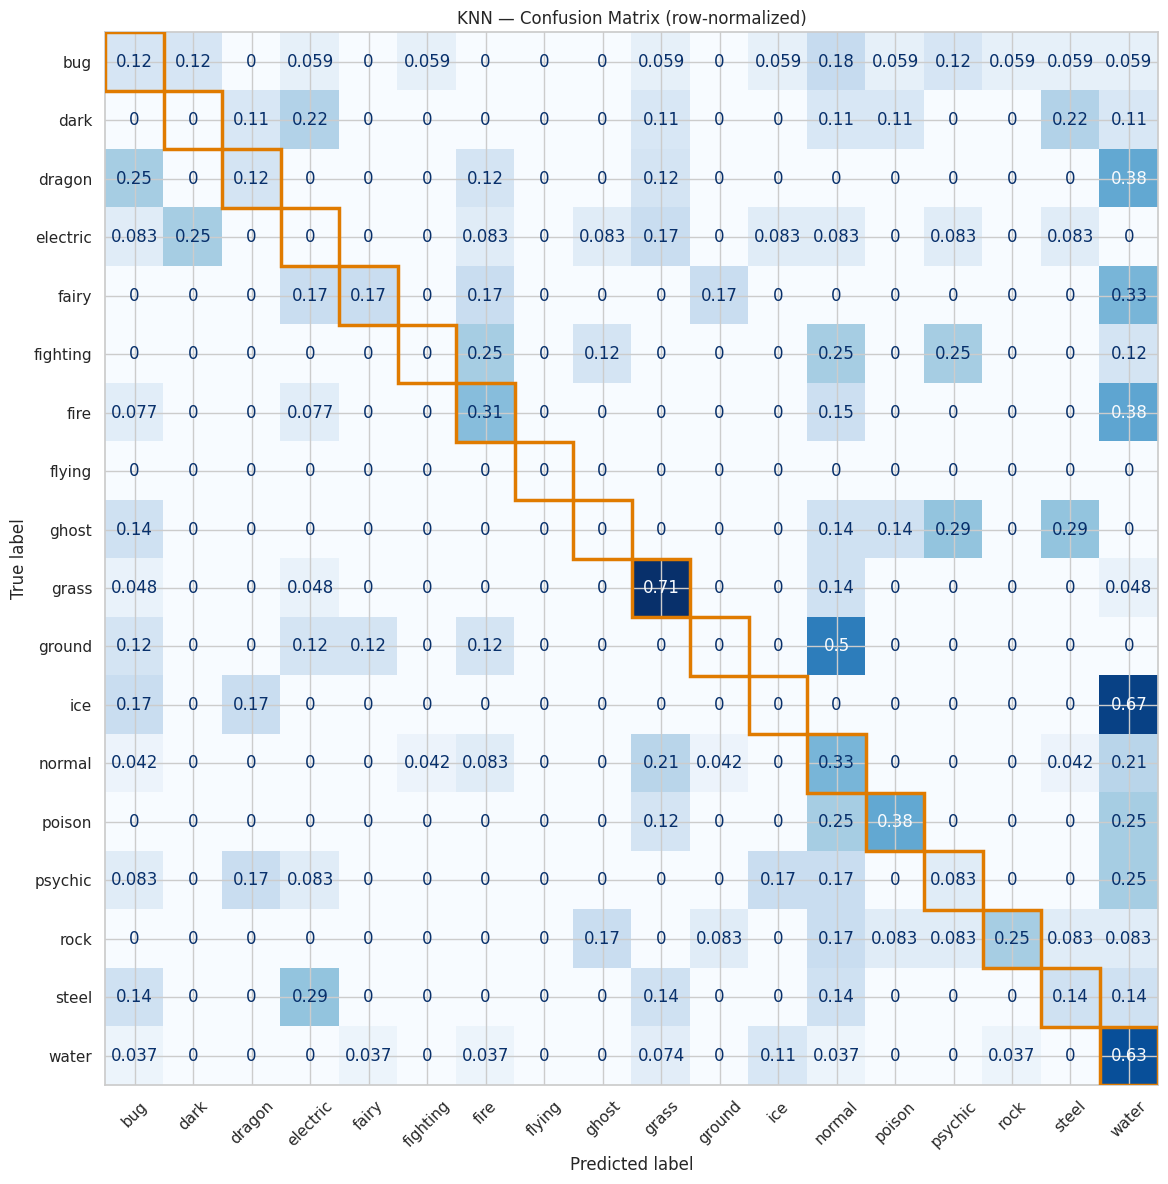

In [198]:
best_pipeline = grid_search.best_estimator_

y_pred = best_pipeline.predict(X_test)

common.print_classification_report(y_test, y_pred, int_to_type)

fig, ax = plt.subplots(figsize=(14, 12))
common.plot_confusion_matrix(y_test, y_pred, int_to_type,
                              title="KNN \u2014 Confusion Matrix (row-normalized)", ax=ax)
plt.show()


Nonetheless, the test f1_macro is too low: 0.17. That is the triple of what a random classifier would do, but still too low. 

We can see a clear dominance of the `Grass` and `Water` types, given their characteristic Green and Blue hue and saturated colors. Fire, normal and poison show a classification score close to 0.3 too. Nevertheless, there are still 7 classes that do not obtain any sample classificated in the right way. The most clear confusion is the misclassification of `Ice` types into the `Water` label. This is highly due to their color similarities (blue hue). We can also see the problem of the imbalance in action: most of the classifications fall into the `Water` and `Normal` labels, the most represented classes.

### 2.2. Per-class F1 vs. class size

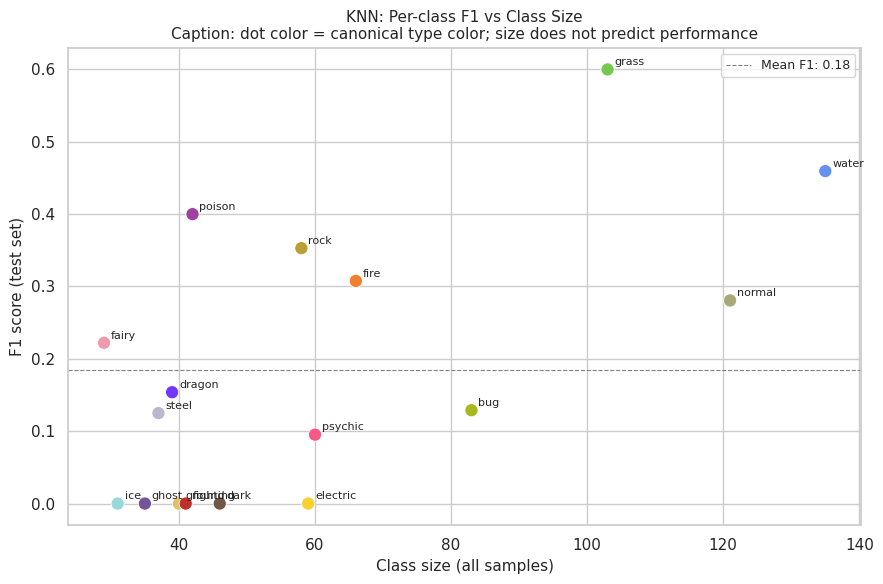

Best F1:   grass (0.60)
Worst F1:  ice (0.00)

Spearman correlation (count vs F1): 0.52


In [199]:
class_counts = df["type1"].value_counts()
f1_per_class = {}
for cls_int in sorted(int_to_type.keys()):
    type_name = int_to_type[cls_int]
    if type_name not in class_counts.index:
        continue
    f1 = f1_score(y_test == cls_int, y_pred == cls_int, zero_division=0)
    f1_per_class[type_name] = {"f1": f1, "count": int(class_counts[type_name])}

f1_df = pd.DataFrame(f1_per_class).T.astype(float).sort_values("count")

fig, ax = plt.subplots(figsize=(9, 6))
colors_f1 = [common.TYPE_COLORS.get(t, "#888") for t in f1_df.index]
ax.scatter(f1_df["count"], f1_df["f1"], c=colors_f1, s=90, zorder=3, edgecolors="white", linewidths=0.6)
for type_name, row_data in f1_df.iterrows():
    ax.annotate(type_name, (row_data["count"], row_data["f1"]),
                xytext=(5, 3), textcoords="offset points", fontsize=8)
mean_f1 = f1_df["f1"].mean()
ax.axhline(mean_f1, color="gray", linestyle="--", linewidth=0.8, label=f"Mean F1: {mean_f1:.2f}")
ax.set_xlabel("Class size (all samples)", fontsize=11)
ax.set_ylabel("F1 score (test set)", fontsize=11)
ax.set_title("KNN: Per-class F1 vs Class Size\n"
             "Caption: dot color = canonical type color; size does not predict performance", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Best F1:  ", f1_df["f1"].idxmax(), f"({f1_df['f1'].max():.2f})")
print("Worst F1: ", f1_df["f1"].idxmin(), f"({f1_df['f1'].min():.2f})")
print(f"\nSpearman correlation (count vs F1): "
      f"{f1_df[['count','f1']].corr(method='spearman').iloc[0,1]:.2f}")

The scatter confirms what the confusion matrix hints: KNN's per-class performance correlates only loosely with class size. Types with  a distinctive, consistent color signature (Water's blue hues, Fire's oranges) and high representation earn relatively high F1. Types that are visually ambiguous and lacking of count do poorly. KNN's weakness is feature-space overlap: if two types share similar color distributions, their neighborhoods intersect and both suffer. The implication for XAI is that misclassifications here are often semantically meaningful as the  predicted type genuinely looks like the true type.

### 2.3. Balancing Strategy: SMOTE

KNN has no `class_weight` parameter so the only native protection against imbalance is weights="distance". A more aggressive remedy is using oversampling. Here we will try SMOTE  (Synthetic Minority Over-sampling Technique): for each minority-class sample, SMOTE generates synthetic points by interpolating between that sample and its k nearest same-class neighbors in feature space, until all classes reach the majority class size.

SMOTE maintains explainability and keeps the theory that same type Pokémon share colors. Importantly, SMOTE is applied **inside** the cross-validation pipeline (via `ImbPipeline`), so synthetic samples are only generated from training folds and never contaminate the validation fold — a critical safeguard against data leakage.

In [200]:
classif_seeded = partial(mutual_info_classif, random_state=42)

pipeline_smote = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)), 
    ('feature_selection', SelectKBest(score_func=classif_seeded)),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    "feature_selection__k": [10, 15, 20, 25, 30, 42],
    "knn__n_neighbors": [3, 5, 7, 9, 13],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan", "chebyshev"] 
}

cv_reproducible = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_smote = GridSearchCV(
    pipeline_smote, 
    param_grid, 
    cv=cv_reproducible, 
    scoring="f1_macro", 
    n_jobs=-1, 
    verbose=1
)

grid_search_smote.fit(X_train, y_train)

print(f"\n--- Final Results ---")
print(f"Best CV f1_macro: {grid_search_smote.best_score_:.4f}")
print(f"Best KNN params: {grid_search_smote.best_params_}")
print(f"Best feature count: {len(grid_search_smote.best_estimator_.named_steps['feature_selection'].get_support(indices=True))}")
print(f"Best feature indices: {grid_search_smote.best_estimator_.named_steps['feature_selection'].get_support(indices=True)}")

if hasattr(X_train, "columns"):
    best_columns = X_train.columns[grid_search_smote.best_estimator_.named_steps['feature_selection'].get_support(indices=True)].tolist()
    print(f"Best feature names: {best_columns}")

Fitting 5 folds for each of 180 candidates, totalling 900 fits

--- Final Results ---
Best CV f1_macro: 0.1974
Best KNN params: {'feature_selection__k': 30, 'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'distance'}
Best feature count: 30
Best feature indices: [ 0  1  2  4  5  8  9 10 11 12 13 14 15 16 20 21 22 23 24 25 26 27 28 29
 30 31 36 39 40 41]
Best feature names: ['dom1_h', 'dom1_s', 'dom1_v', 'dom2_h', 'dom2_s', 'dom3_h', 'dom3_s', 'dom3_v', 'dom3_prop', 'dom4_h', 'dom4_s', 'dom4_v', 'dom4_prop', 'dom5_h', 'mean_h_sin', 'mean_h_cos', 'mean_s', 'mean_v', 'std_s', 'std_v', 'std_hue_angular', 'prop_dark', 'prop_saturated', 'color_diversity', 'hue_bin_0', 'hue_bin_30', 'hue_bin_180', 'hue_bin_270', 'hue_bin_300', 'hue_bin_330']


              precision    recall  f1-score   support

         bug       0.05      0.06      0.06        17
        dark       0.50      0.33      0.40         9
      dragon       0.09      0.12      0.11         8
    electric       0.18      0.17      0.17        12
       fairy       0.12      0.17      0.14         6
    fighting       0.25      0.25      0.25         8
        fire       0.17      0.15      0.16        13
      flying       0.00      0.00      0.00         0
       ghost       0.18      0.29      0.22         7
       grass       0.50      0.52      0.51        21
      ground       0.09      0.12      0.11         8
         ice       0.11      0.17      0.13         6
      normal       0.33      0.12      0.18        24
      poison       0.29      0.25      0.27         8
     psychic       0.20      0.17      0.18        12
        rock       0.25      0.50      0.33        12
       steel       0.00      0.00      0.00         7
       water       0.32    

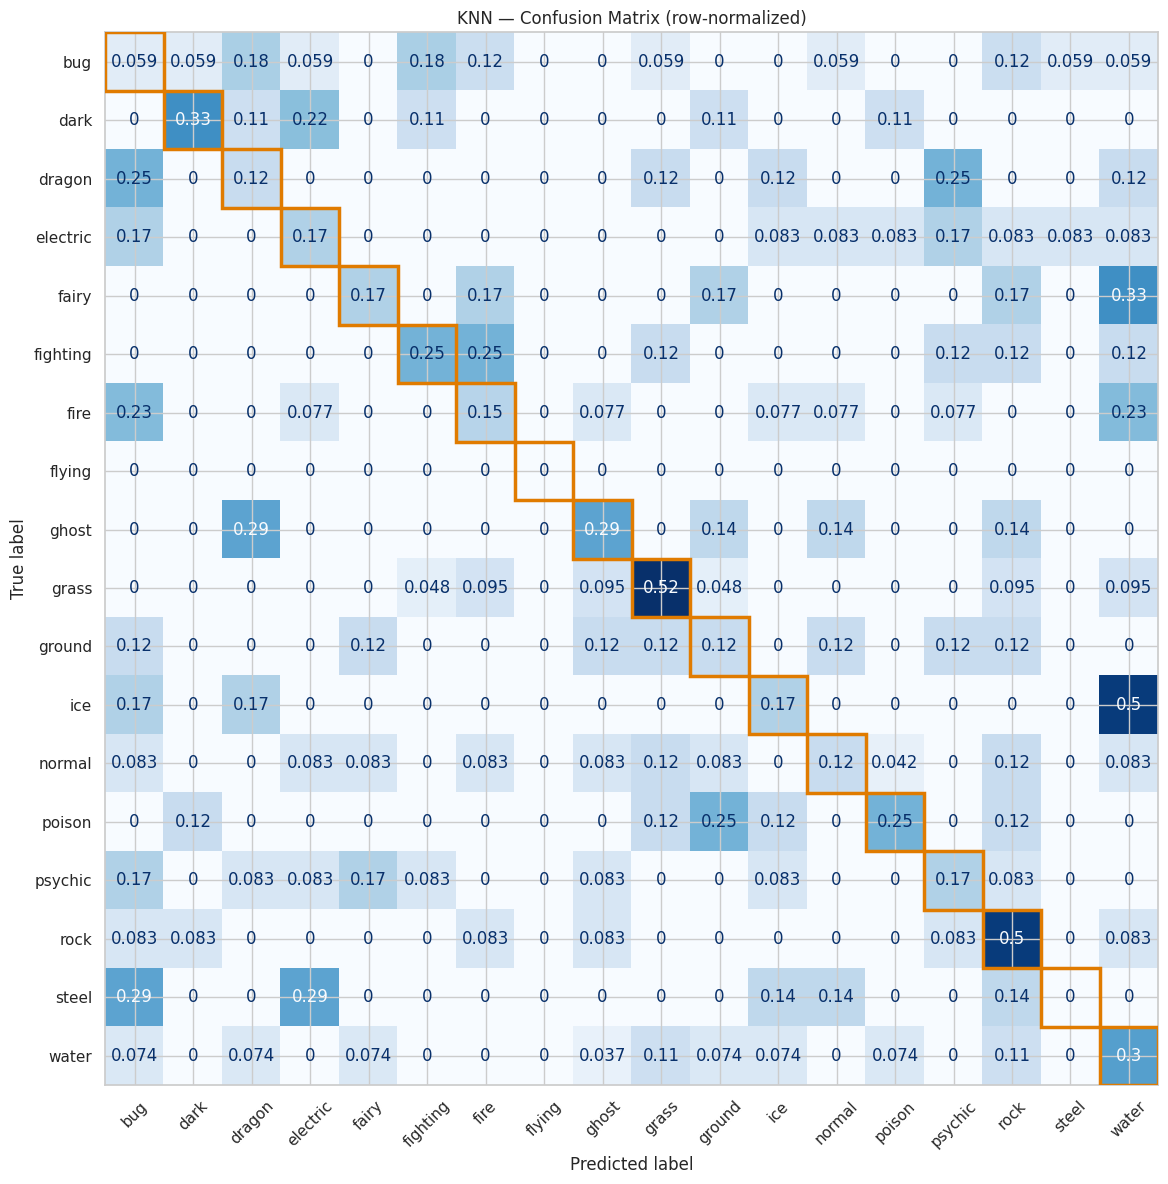

In [201]:
best_pipeline_smote = grid_search_smote.best_estimator_

y_pred_smote = best_pipeline_smote.predict(X_test)

common.print_classification_report(y_test, y_pred_smote, int_to_type)

fig, ax = plt.subplots(figsize=(14, 12))
common.plot_confusion_matrix(y_test, y_pred_smote, int_to_type,
                              title="KNN \u2014 Confusion Matrix (row-normalized)", ax=ax)
plt.show()

The score metric decrease by a bit. In the next cell we can see a fair comparison of what happened.

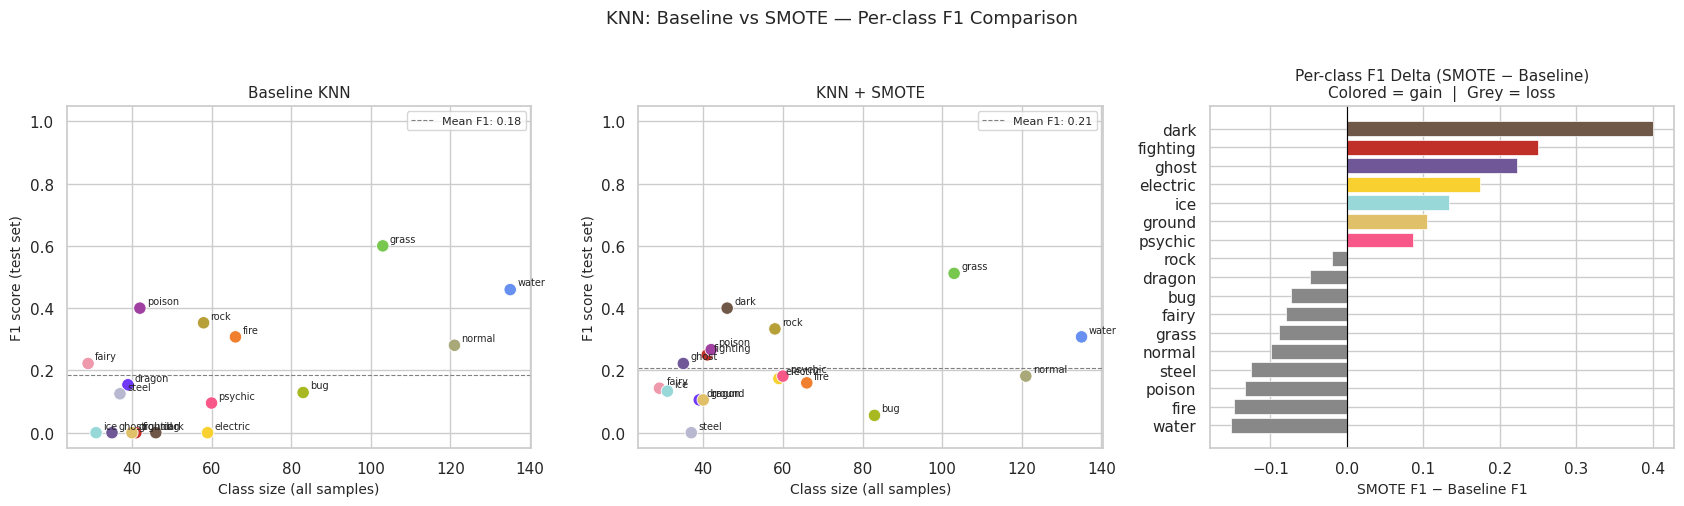


Model            Accuracy   f1_macro
------------------------------------
Baseline           0.2732     0.1839
SMOTE              0.2341     0.2077

Spearman correlation (class size vs F1 delta): -0.41
Types that improved:  7
Types that worsened:  10
Largest gain:  dark (+0.400)
Largest loss:  water (-0.152)


In [202]:
# --- Build per-class F1 for both models ---
def per_class_f1(y_true, y_pred_arr):
    result = {}
    for cls_int in sorted(int_to_type.keys()):
        type_name = int_to_type[cls_int]
        if type_name not in class_counts.index:
            continue
        f1 = f1_score(y_true == cls_int, y_pred_arr == cls_int, zero_division=0)
        result[type_name] = {"f1": f1, "count": int(class_counts[type_name])}
    return pd.DataFrame(result).T.astype(float)

f1_baseline = per_class_f1(y_test, y_pred)
f1_smote    = per_class_f1(y_test, y_pred_smote)
types_shared = f1_baseline.index.intersection(f1_smote.index)
f1_baseline  = f1_baseline.loc[types_shared]
f1_smote     = f1_smote.loc[types_shared]
delta        = (f1_smote["f1"] - f1_baseline["f1"]).sort_values()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, f1_df, title in [
    (axes[0], f1_baseline, "Baseline KNN"),
    (axes[1], f1_smote,    "KNN + SMOTE"),
]:
    colors_sc = [common.TYPE_COLORS.get(t, "#888") for t in f1_df.index]
    ax.scatter(f1_df["count"], f1_df["f1"],
               c=colors_sc, s=80, zorder=3, edgecolors="white", linewidths=0.6)
    for type_name, row_data in f1_df.iterrows():
        ax.annotate(type_name, (row_data["count"], row_data["f1"]),
                    xytext=(5, 3), textcoords="offset points", fontsize=7)
    mean_f1 = f1_df["f1"].mean()
    ax.axhline(mean_f1, color="gray", linestyle="--", linewidth=0.8,
               label=f"Mean F1: {mean_f1:.2f}")
    ax.set_xlabel("Class size (all samples)", fontsize=10)
    ax.set_ylabel("F1 score (test set)", fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)

# Delta bar chart
bar_colors = [
    common.TYPE_COLORS.get(t, "#888") if v >= 0 else "#888888"
    for t, v in delta.items()
]
axes[2].barh(delta.index, delta.values, color=bar_colors, edgecolor="white", linewidth=0.5)
axes[2].axvline(0, color="black", linewidth=0.8)
axes[2].set_xlabel("SMOTE F1 − Baseline F1", fontsize=10)
axes[2].set_title("Per-class F1 Delta (SMOTE − Baseline)\nColored = gain  |  Grey = loss", fontsize=11)

fig.suptitle("KNN: Baseline vs SMOTE — Per-class F1 Comparison", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"\n{'Model':<14} {'Accuracy':>10} {'f1_macro':>10}")
print("-" * 36)
print(f"{'Baseline':<14} {accuracy_score(y_test, y_pred):>10.4f} "
      f"{f1_score(y_test, y_pred, average='macro', zero_division=0):>10.4f}")
print(f"{'SMOTE':<14} {accuracy_score(y_test, y_pred_smote):>10.4f} "
      f"{f1_score(y_test, y_pred_smote, average='macro', zero_division=0):>10.4f}")

delta_spearman = delta.reset_index()
delta_spearman.columns = ["type", "delta"]
delta_spearman["count"] = [f1_baseline.loc[t, "count"] for t in delta_spearman["type"]]
corr_val = delta_spearman[["count", "delta"]].corr(method="spearman").iloc[0, 1]
print(f"\nSpearman correlation (class size vs F1 delta): {corr_val:.2f}")
print(f"Types that improved:  {(delta > 0).sum()}")
print(f"Types that worsened:  {(delta < 0).sum()}")
print(f"Largest gain:  {delta.idxmax()} ({delta.max():+.3f})")
print(f"Largest loss:  {delta.idxmin()} ({delta.min():+.3f})")

In conclusion, the application of SMOTE to address severe class imbalance within the 42-dimensional color feature space yielded a fundamental trade-off between absolute accuracy and class-level fairness. While the overall test accuracy decreases from 27.32% to 23.41%, the macro F1 score improved from 0.1839 to 0.2077. This dynamic is structurally validated by the moderate negative Spearman correlation (-0.41) between the original class size and the F1 score delta, demonstrating a systematic redistribution of predictive performance.

Previously undetectable minority classes, such as `Dark` (+0.4) and `Fighting` now have a chance to be detected. From an explainable AI perspective, the synthetic generation of minority samples successfully populated sparse regions of the multidimensional space. This prevented the KNN algorithm from overwhelming underrepresented instances with the sheer volume of majority-class neighbors. Ultimately, the SMOTE-enhanced pipeline abandons the bias of raw probability in favor of a more robust, geometrically equitable classification system.

## 3. ML explanation

### 3.1. Global explanations

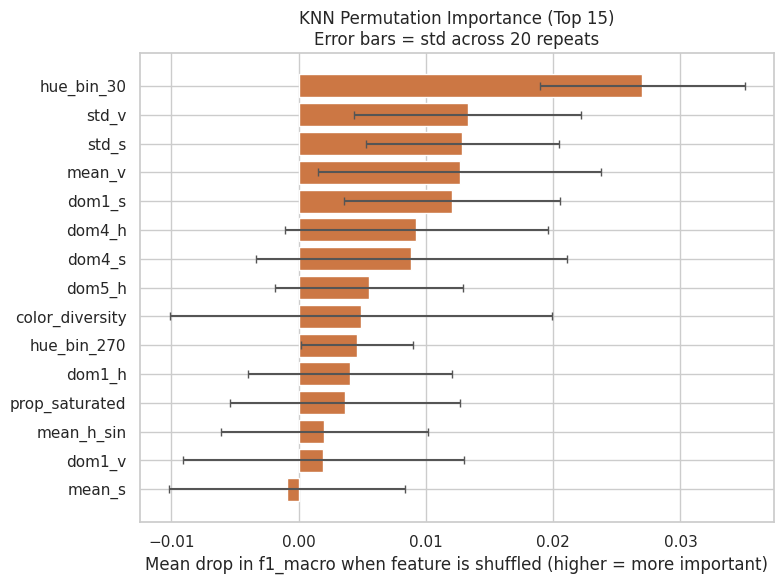

In [203]:
scaler = best_pipeline_smote.named_steps['scaler']
selector = best_pipeline_smote.named_steps['feature_selection']
knn_model = best_pipeline_smote.named_steps['knn']

# Keep X_test_scaled as a DataFrame so .iloc[] works in the local explanation function
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    index=X_test.index,
    columns=X_test.columns
)
X_test_selected = selector.transform(X_test_scaled)

mascara_variables = selector.get_support()
nombres_caracteristicas = X_test.columns[mascara_variables].tolist()

perm_imp = permutation_importance(
    knn_model,
    X_test_selected,
    y_test,
    n_repeats=20,
    random_state=common.RANDOM_STATE,
    scoring="f1_macro"
)

perm_series = pd.Series(perm_imp.importances_mean, index=nombres_caracteristicas).nlargest(15)

fig, ax = plt.subplots(figsize=(8, 6))
# Show error bars to indicate reliability of each importance estimate
ax.barh(
    perm_series.sort_values().index,
    perm_series.sort_values().values,
    xerr=pd.Series(perm_imp.importances_std, index=nombres_caracteristicas)
        .loc[perm_series.sort_values().index].values,
    color="#cc7744", ecolor="#555555", capsize=3
)
ax.set_title("KNN Permutation Importance (Top 15)\nError bars = std across 20 repeats")
ax.set_xlabel("Mean drop in f1_macro when feature is shuffled (higher = more important)")
plt.tight_layout()
plt.show()

# Build X_train_scaled (42-dim) — needed by LIME in the local explanation
X_train_scaled = pd.DataFrame(
    scaler.transform(X_train),
    index=X_train.index,
    columns=X_train.columns
)


The permutation importance ranking reveals that **`hue_bin_30`** (the orange–yellow hue range, 30°–60°) is the single most important feature for KNN classification, followed by measures of sprite colour variability (`std_v`, `std_s`) and brightness (`mean_v`). Dominant-colour descriptors (`dom1_s`, `dom4_h`, `dom4_s`, `dom5_h`) and `color_diversity` also contribute positively, confirming that KNN relies on both the overall palette "feel" and specific hue signals.

Conversely, several features yield **negative importance** — shuffling them actually *improves* f1_macro. These features inject geometric noise into the Manhattan distance computation without adding discriminative signal. In the next step we prune them, keeping only the 14 features with strictly positive importance.

In [204]:
features_positivas = perm_series[perm_series > 0].index.tolist()

print(f"Variables seleccionadas tras diagnóstico XAI ({len(features_positivas)}):")
print(features_positivas)

X_train_clean = X_train[features_positivas]
X_test_clean = X_test[features_positivas]

mejor_n = best_pipeline_smote.named_steps['knn'].n_neighbors
mejor_weight = best_pipeline_smote.named_steps['knn'].weights
mejor_metric = best_pipeline_smote.named_steps['knn'].metric

pipeline_final = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier(
        n_neighbors=mejor_n, 
        weights=mejor_weight, 
        metric=mejor_metric
    ))
])

print("\nEntrenando el modelo depurado...")
pipeline_final.fit(X_train_clean, y_train)

y_pred_final = pipeline_final.predict(X_test_clean)
f1_macro_final = f1_score(y_test, y_pred_final, average='macro')

print(f"F1 Macro del modelo depurado en Test: {f1_macro_final:.4f}")

Variables seleccionadas tras diagnóstico XAI (14):
['hue_bin_30', 'std_v', 'std_s', 'mean_v', 'dom1_s', 'dom4_h', 'dom4_s', 'dom5_h', 'color_diversity', 'hue_bin_270', 'dom1_h', 'prop_saturated', 'mean_h_sin', 'dom1_v']

Entrenando el modelo depurado...
F1 Macro del modelo depurado en Test: 0.1870


In [205]:
# ── Explanation-only KNN ─────────────────────────────────────────────────────
# pipeline_final uses SMOTE, so its internal KNN was fit on synthetic + real
# data. Neighbor indices would point to synthetic samples, not real Pokémon.
# We fit a separate KNN on the REAL training data (same hyperparams, same
# pruned features) so that every neighbor is a real, displayable Pokémon.

scaler_explain = StandardScaler()
X_train_explain = pd.DataFrame(
    scaler_explain.fit_transform(X_train_clean),
    index=X_train_clean.index,
    columns=features_positivas
)
X_test_explain = pd.DataFrame(
    scaler_explain.transform(X_test_clean),
    index=X_test_clean.index,
    columns=features_positivas
)

knn_explain = KNeighborsClassifier(
    n_neighbors=mejor_n, weights=mejor_weight, metric=mejor_metric
)
knn_explain.fit(X_train_explain, y_train)

print(f"Explanation KNN fitted on {len(X_train_explain)} real samples, "
      f"{len(features_positivas)} features")
print(f"Test accuracy (no SMOTE): {knn_explain.score(X_test_explain, y_test):.4f}")


Explanation KNN fitted on 820 real samples, 14 features
Test accuracy (no SMOTE): 0.2537


The explanation KNN is a copy of the final model's hyperparameters but trained **without SMOTE** on the real training data. This ensures that every neighbor returned by `kneighbors()` maps to a real Pokémon sprite we can display. The slight accuracy difference (if any) between this and `pipeline_final` reflects the SMOTE effect, not a modelling error.

To validate the insights gained from the permutation importance analysis we prune the feature set, eliminating every variable with negative importance. After this process we are left with **14 variables** and obtain an F1_macro of **0.1870** on the test set — still above the 42-feature baseline (0.17). This trade-off illustrates the Principle of Parsimony in machine learning: we sacrifice a marginal degree of performance to eliminate geometric noise from the distance computation. The final classifier operates in a significantly lower-dimensional space, which should make its neighbour-based explanations cleaner and easier to interpret.

Computing SHAP values...


100%|██████████| 80/80 [00:26<00:00,  2.98it/s]

Done.


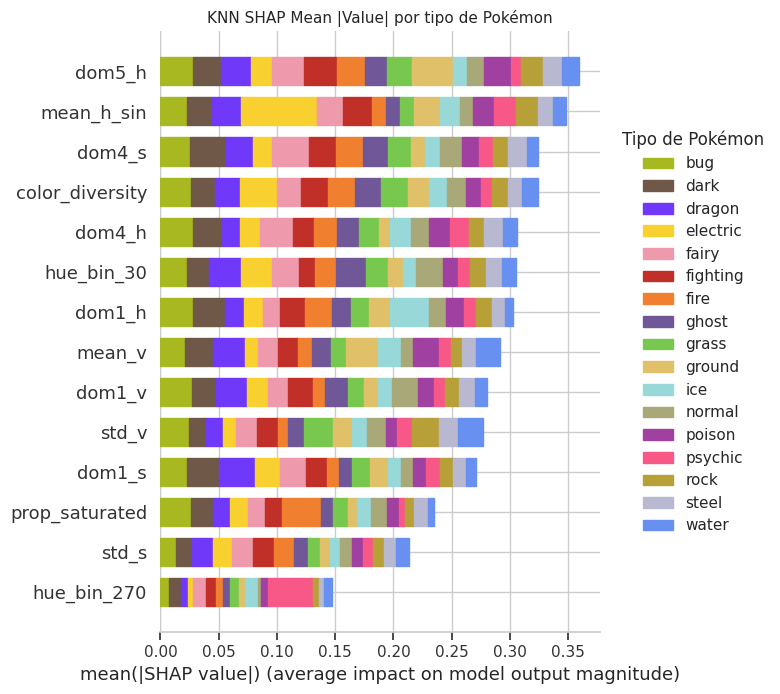

In [206]:

print("Computing SHAP values...")
background = shap.kmeans(X_train_clean, 100)

np.random.seed(42)
shap_sample_idx = np.random.choice(len(X_test_clean), size=80, replace=False)
X_test_shap = X_test_clean.iloc[shap_sample_idx]

def pipeline_predict_wrapper(X_array):
    X_df = pd.DataFrame(X_array, columns=X_train_clean.columns)
    return pipeline_final.predict_proba(X_df)

kernel_explainer = shap.KernelExplainer(pipeline_predict_wrapper, background)

shap_values_knn = kernel_explainer.shap_values(X_test_shap, nsamples=200)
print("Done.")

fig, ax = plt.subplots(figsize=(15, 10))

clases_modelo = pipeline_final.named_steps['knn'].classes_
nombres_clases = [int_to_type[c] for c in clases_modelo]
colores_clases = [common.TYPE_COLORS.get(name, "#888888") for name in nombres_clases]
cmap_pokemon = mcolors.ListedColormap(colores_clases)


shap.summary_plot(
    shap_values_knn, 
    X_test_shap, 
    plot_type="bar",
    class_names=nombres_clases,
    show=False, 
    max_display=14
)

ax = plt.gca()
num_features_shown = len(ax.patches) // len(nombres_clases)


for i, patch in enumerate(ax.patches):
    class_idx = i // num_features_shown 
    color_correcto = colores_clases[class_idx]
    
    patch.set_facecolor(color_correcto)
    patch.set_edgecolor(color_correcto)

legend_handles = [
    mpatches.Patch(color=colores_clases[i], label=nombres_clases[i]) 
    for i in range(len(nombres_clases))
]

ax.legend(
    handles=legend_handles, 
    loc='center left', 
    bbox_to_anchor=(1.02, 0.5),
    title="Tipo de Pokémon",
    frameon=False
)

plt.title("KNN SHAP Mean |Value| por tipo de Pokémon", fontsize=11)
plt.tight_layout()
plt.show()

Using SHAP, we extract the following conclusions:

1. The features `dom5_h` and `mean_h_sin` are among the most globally impactful variables across all classes. Both encode hue information — one for the fifth-most-prominent colour cluster, the other as a circular summary of the overall palette — confirming that hue is the primary discriminative axis.
2. `color_diversity` ranks high globally. Whether a Pokémon has a monochromatic palette or a varied one is a strong universal differentiator for KNN, since it directly affects distances in the feature space.
3. The `Electric` type is disproportionately characterised by `mean_h_sin`, which makes contextual sense: Electric Pokémon are typically yellow, mapping to a specific sine-encoded hue value.
4. `hue_bin_270` has low average global impact, yet a large share of its SHAP magnitude is driven by the `Psychic` type. This hue bucket (purple–pink range) is not useful for most types but acts as a strong signal for Psychic Pokémon.
5. For `Dark` and `Ghost` types, value and saturation features (`mean_v`, `dom1_v`, `dom1_s`) carry more relative weight than the hue features that dominate other types. This aligns with the visual design of these types: dark, desaturated palettes rather than distinctive hues.

#### SHAP Beeswarm: Class-Level Feature Effects (Water, Fire, Grass, Dark)

The bar chart above shows **magnitude** of SHAP values. The beeswarm below shows **direction**: does a high feature value push the model *toward* or *away from* predicting a given type? We select four types with distinct color signatures to illustrate the difference.

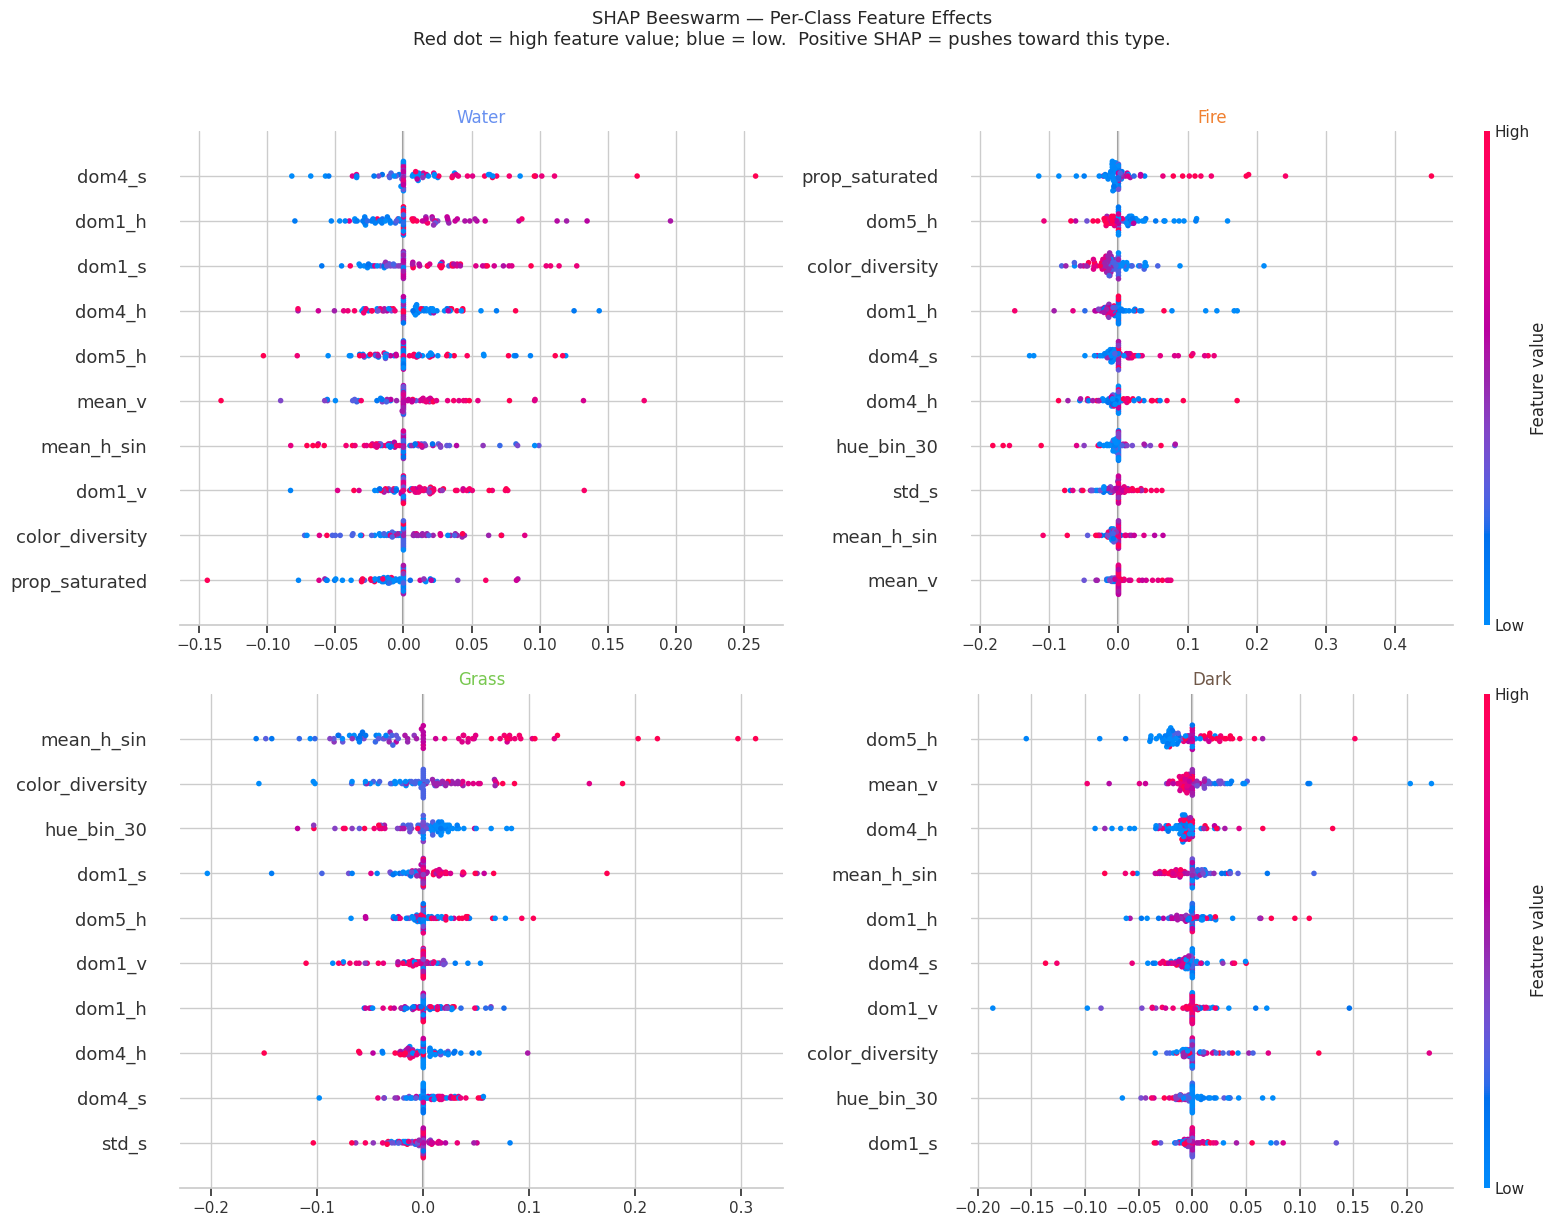

In [207]:
# ── SHAP beeswarm for 4 representative types ────────────────────────────────
target_types = ["water", "fire", "grass", "dark"]
clases_modelo = pipeline_final.named_steps['knn'].classes_
nombres_clases = [int_to_type[c] for c in clases_modelo]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes_flat = axes.flatten()

for ax_i, tname in enumerate(target_types):
    cls_int = type_to_int[tname]
    if cls_int not in clases_modelo:
        axes_flat[ax_i].set_title(f"{tname} — not in model classes")
        continue
    cls_pos = list(clases_modelo).index(cls_int)

    # shap_values_knn shape: (n_samples, n_features, n_classes)
    sv_class = shap_values_knn[:, :, cls_pos]

    plt.sca(axes_flat[ax_i])
    shap.summary_plot(
        sv_class,
        X_test_shap,
        plot_type="dot",
        show=False,
        max_display=10,
        plot_size=None,
        color_bar=ax_i in [1, 3],  # only right-side plots get color bar
    )
    type_color = common.TYPE_COLORS.get(tname, "#888")
    axes_flat[ax_i].set_title(f"{tname.capitalize()}", fontsize=12, color=type_color)
    axes_flat[ax_i].set_xlabel("")

fig.suptitle("SHAP Beeswarm — Per-Class Feature Effects\n"
             "Red dot = high feature value; blue = low.  "
             "Positive SHAP = pushes toward this type.",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


The beeswarms reveal directional effects invisible in the bar chart:

- **Water:** High values of `mean_h_sin` and low `hue_bin_30` push strongly *toward* Water. Water Pokémon have blue palettes whose circular hue encoding differs sharply from the warm-hue range captured by `hue_bin_30`. High `color_diversity` also pushes toward Water — many Water Pokémon feature multi-toned designs (body + fins, shells, etc.).
- **Fire:** Nearly the opposite pattern: high `hue_bin_30` (orange–red range) is the strongest positive driver, while high `mean_h_sin` pushes *away*. Fire is the most chromatically "pure" type — the SHAP dots cluster tightly, indicating consistent colour-based classification.
- **Grass:** `dom5_h` and `mean_h_sin` are key drivers. High `color_diversity` also has a positive effect — Grass Pokémon tend to have varied palettes (green body + flowers, vines, colourful accents).
- **Dark:** Unlike the hue-driven types above, Dark is driven by *value and saturation*: low `mean_v` (dark sprites) and low `dom1_s` push toward Dark. Hue features matter less — it is the absence of brightness and saturation that defines this type chromatically.

#### Decision Boundary Visualization (2D PCA Projection)

To visualize how the KNN model partitions the feature space, we project the pruned features into 2D via PCA and plot the model's decision regions. Each background color represents the type the model would predict at that point. Overlaid dots are real test Pokémon.

**Caveat:** PCA collapses 14 dimensions into 2, so the boundaries are approximate projections. Regions that appear overlapping in 2D may be well-separated in higher dimensions.

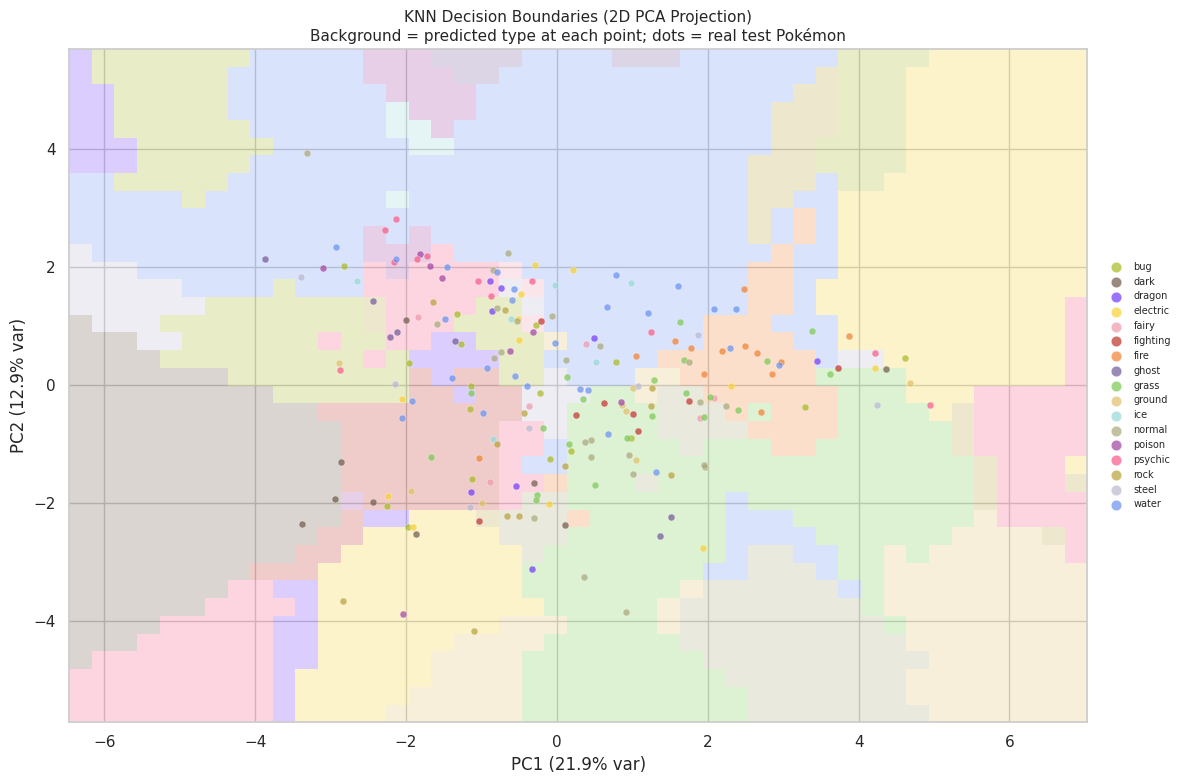

PCA explained variance (2 PCs): 34.8%


In [208]:
# ── Decision boundary in PCA space ──────────────────────────────────────────
pca_db = PCA(n_components=2, random_state=42)
X_train_pca = pca_db.fit_transform(X_train_explain.values)
X_test_pca  = pca_db.transform(X_test_explain.values)

# Meshgrid over the PCA range
margin = 1.5
x_min, x_max = X_train_pca[:, 0].min() - margin, X_train_pca[:, 0].max() + margin
y_min, y_max = X_train_pca[:, 1].min() - margin, X_train_pca[:, 1].max() + margin
h = 0.3  # step size
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Inverse-project each grid point to the pruned feature space and predict
grid_pca = np.c_[xx.ravel(), yy.ravel()]
grid_features = pca_db.inverse_transform(grid_pca)
grid_pred = knn_explain.predict(grid_features)
grid_pred = grid_pred.reshape(xx.shape)

# Build a colormap from TYPE_COLORS
all_classes = sorted(knn_explain.classes_)
class_colors = [common.TYPE_COLORS.get(int_to_type[c], "#888888") for c in all_classes]
from matplotlib.colors import ListedColormap, BoundaryNorm
cmap_bg = ListedColormap(class_colors)
bounds = [c - 0.5 for c in all_classes] + [all_classes[-1] + 0.5]
norm_bg = BoundaryNorm(bounds, cmap_bg.N)

fig, ax = plt.subplots(figsize=(12, 8))
ax.pcolormesh(xx, yy, grid_pred, cmap=cmap_bg, norm=norm_bg, alpha=0.25, shading="auto")

# Plot test points
for cls_int in all_classes:
    type_name = int_to_type[cls_int]
    mask = (y_test.values == cls_int)
    ax.scatter(
        X_test_pca[mask, 0], X_test_pca[mask, 1],
        c=common.TYPE_COLORS.get(type_name, "#888"),
        label=type_name, s=25, alpha=0.7,
        edgecolors="white", linewidths=0.3
    )

ax.set_xlabel(f"PC1 ({pca_db.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca_db.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("KNN Decision Boundaries (2D PCA Projection)\n"
             "Background = predicted type at each point; dots = real test Pokémon",
             fontsize=11)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=7,
          ncol=1, markerscale=1.5, frameon=False)
plt.tight_layout()
plt.show()

print(f"PCA explained variance (2 PCs): {pca_db.explained_variance_ratio_.sum()*100:.1f}%")


The decision boundary plot reveals the geometric nature of KNN classification:

- Types with concentrated colour signatures (Fire, Water, Grass, Electric) form **coherent regions** in the projection, visible as distinct patches.
- Types with diffuse or overlapping colour profiles (Normal, Rock, Ground, Dark) share territory, explaining the low per-class F1 scores seen earlier.
- The boundary complexity is high — KNN produces highly non-linear, "jagged" decision surfaces because each prediction depends only on the local neighbourhood. This contrasts with the smoother boundaries a Decision Tree would produce.
- The 2 PCA components capture only **34.8%** of the total variance, so apparent overlap in this projection may resolve in the full 14-dimensional space.

### 3.2. Local explanation

In [209]:

EXPLAIN_IDS = common.EXPLAIN_IDS.copy()
fallbacks = {
    "correct_clear":      9,   # Blastoise (water) — reliably classified
    "correct_surprise":   None,
    "misclass_secondary": None,
    "misclass_wrong":     None,
}
for k_key, v in fallbacks.items():
    if EXPLAIN_IDS[k_key] is None and v is not None:
        EXPLAIN_IDS[k_key] = v

explain_cases = {k: v for k, v in EXPLAIN_IDS.items() if v is not None}
print("Explaining:", explain_cases)


Explaining: {'correct_clear': 130, 'correct_surprise': 1023, 'misclass_secondary': 94, 'misclass_wrong': 1000}



[CORRECT_CLEAR]  Gyarados  (#130)
  True type  : water
  Predicted  : fighting  ✗
  Type 2     : flying


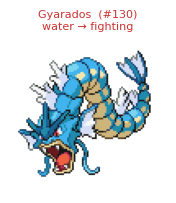


  3 Nearest Neighbours (scaled, pruned feature space):
  Name                   Type1        Type2           Dist
  ---------------------------------------------------------
  Piplup                 water        —              5.161
  Zamazenta              fighting     —              5.259
  Clawitzer              water        —              5.703


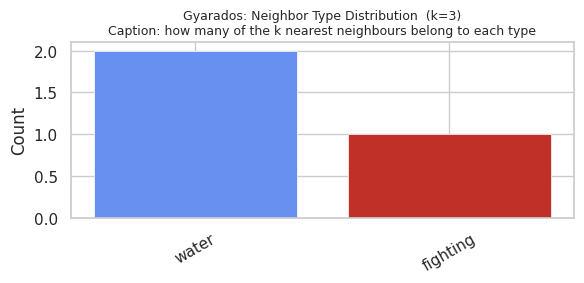

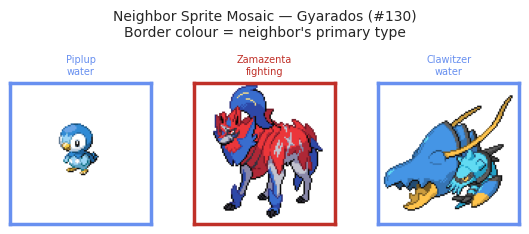

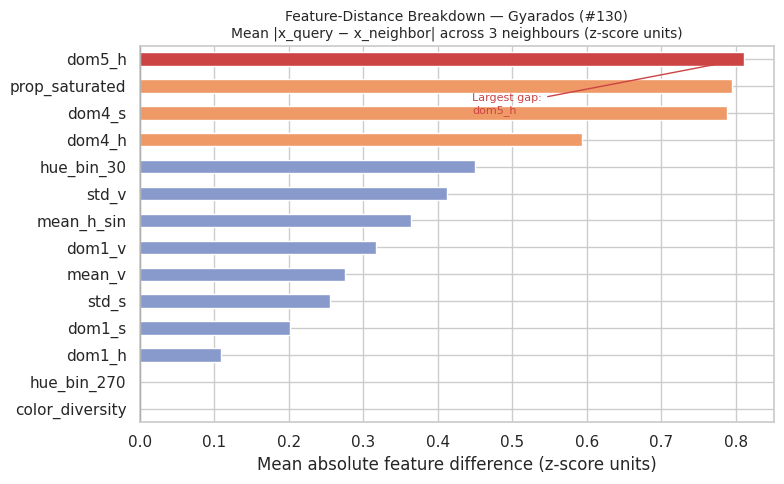

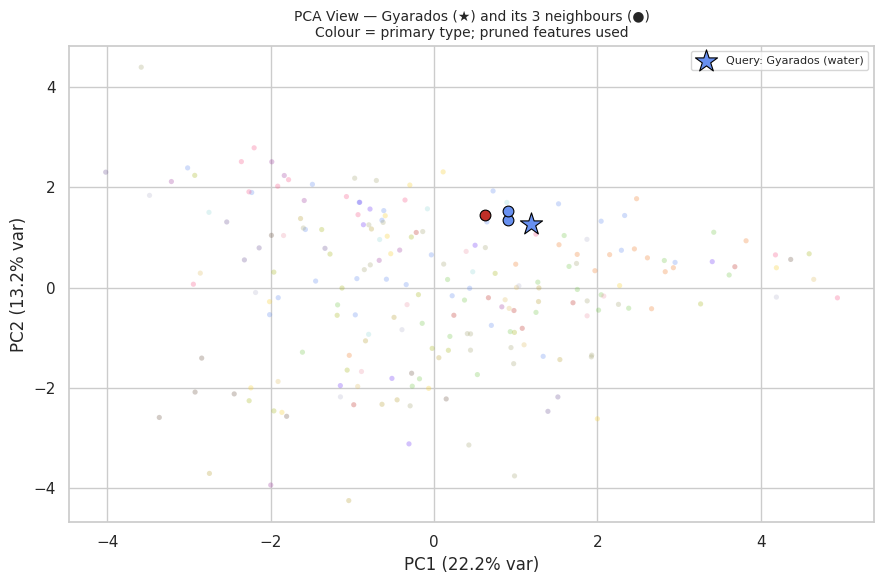

  [SHAP] Instance not in pre-computed sample — skipping waterfall.
  Re-run the SHAP cell with this index added to shap_sample_idx.


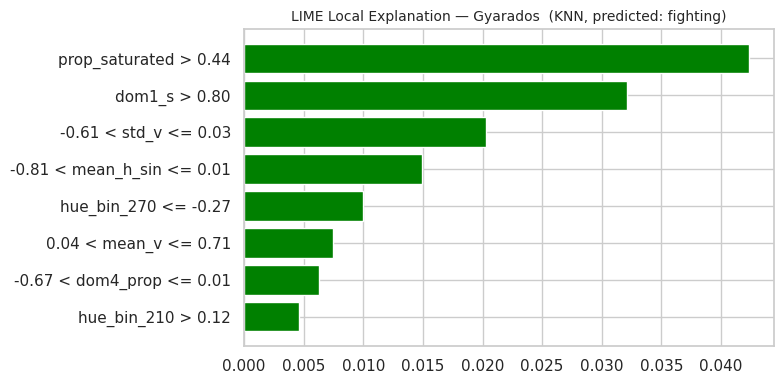


[CORRECT_SURPRISE]  Iron-crown  (#1023)
  True type  : steel
  Predicted  : bug  ✗
  Type 2     : psychic


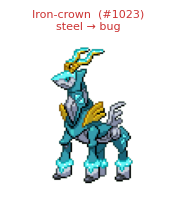


  3 Nearest Neighbours (scaled, pruned feature space):
  Name                   Type1        Type2           Dist
  ---------------------------------------------------------
  Cobalion               steel        fighting       5.730
  Surskit                bug          water          6.053
  Quaxwell               water        —              6.373


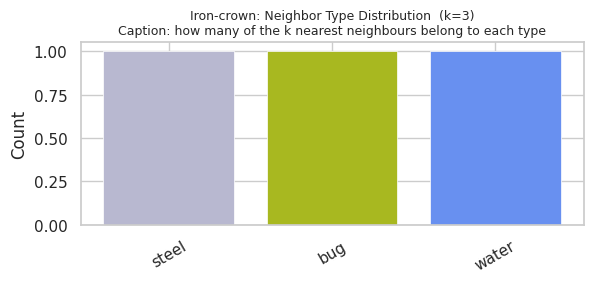

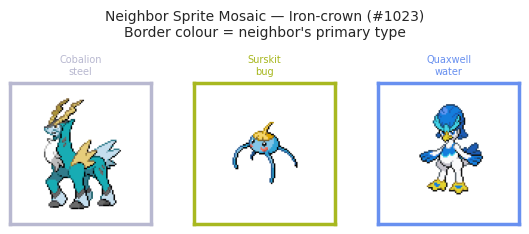

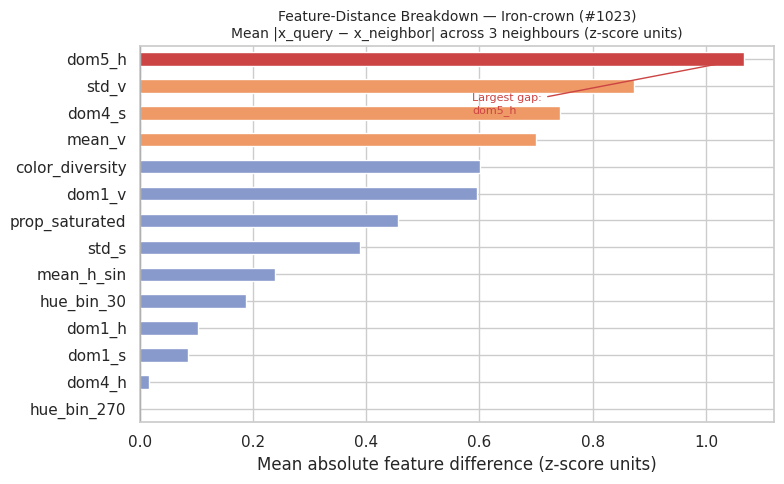

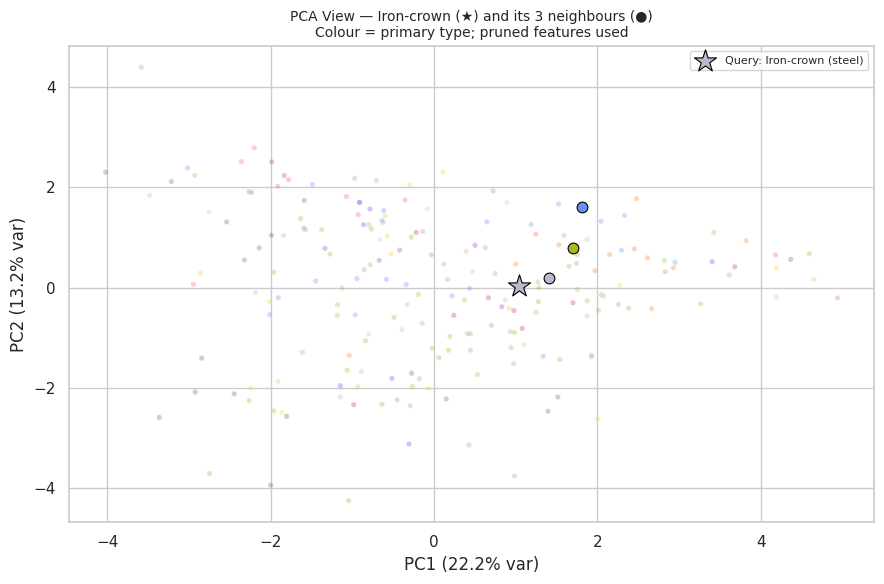

  [SHAP] Instance not in pre-computed sample — skipping waterfall.
  Re-run the SHAP cell with this index added to shap_sample_idx.


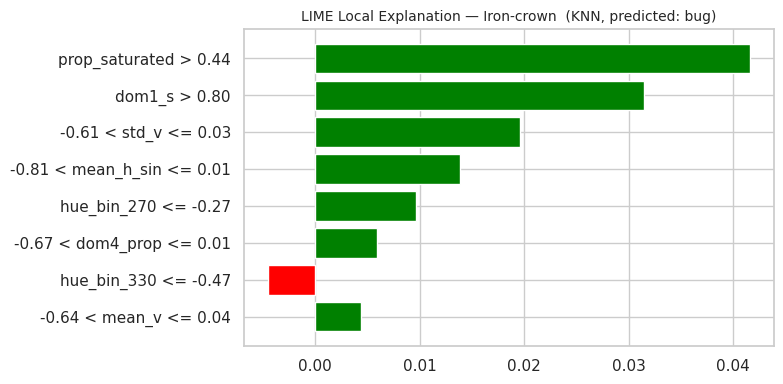


[MISCLASS_SECONDARY]  Gengar  (#94)
  True type  : ghost
  Predicted  : poison  ✗
  Type 2     : poison
  ★ Predicted type matches secondary type — classic color-confusion case!


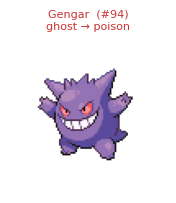


  3 Nearest Neighbours (scaled, pruned feature space):
  Name                   Type1        Type2           Dist
  ---------------------------------------------------------
  Mismagius              ghost        —              7.035
  Nidoran-m              poison       —              7.149
  Muk                    poison       —              7.273


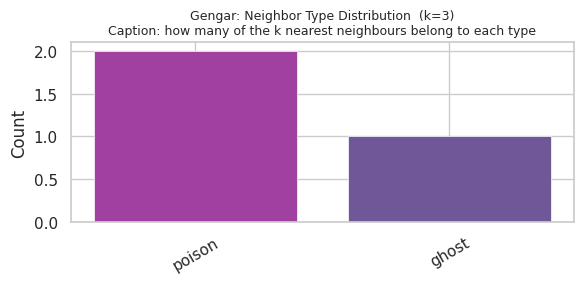

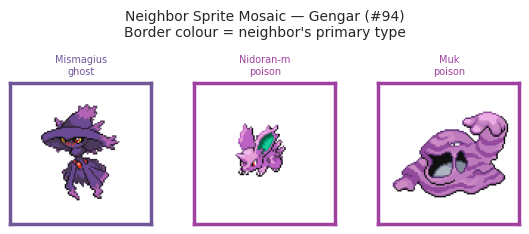

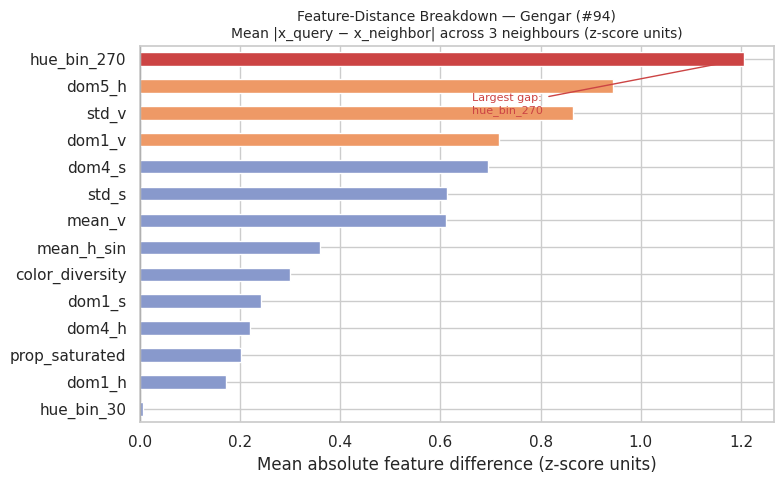

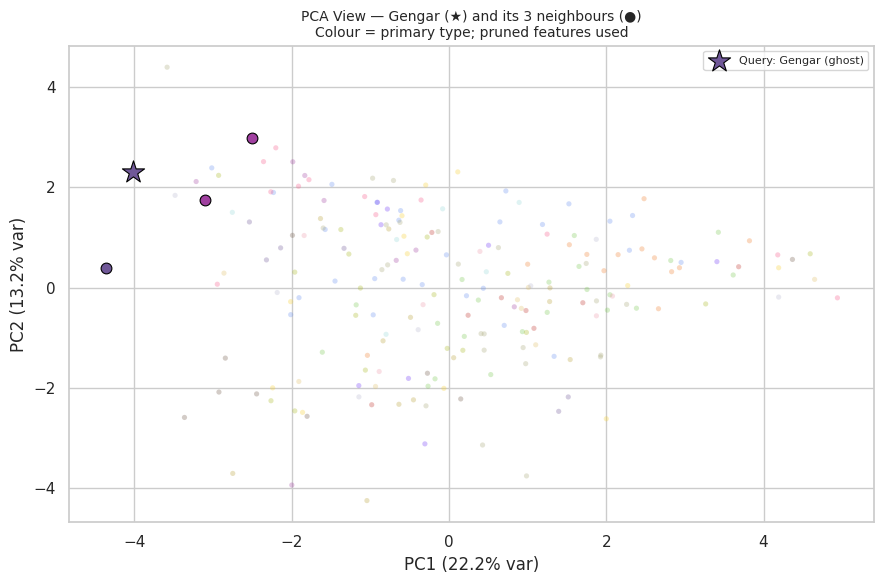

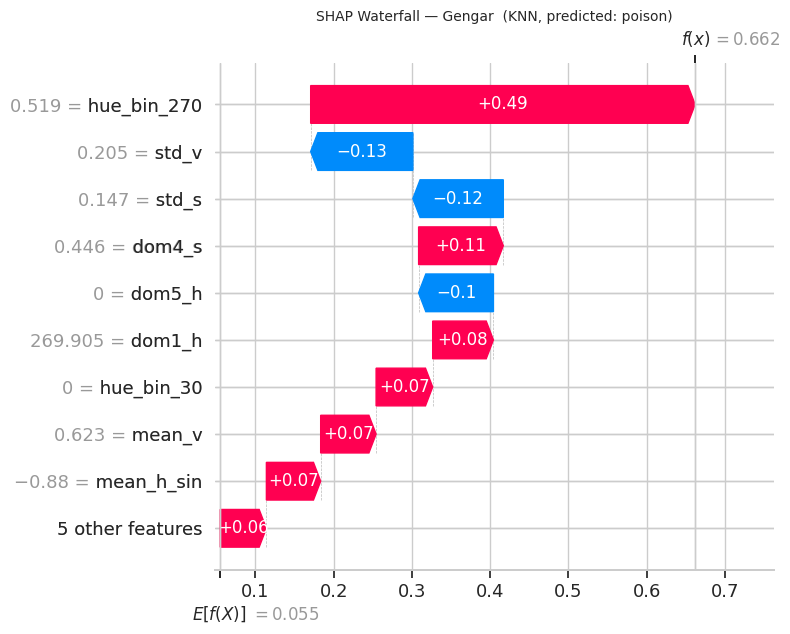

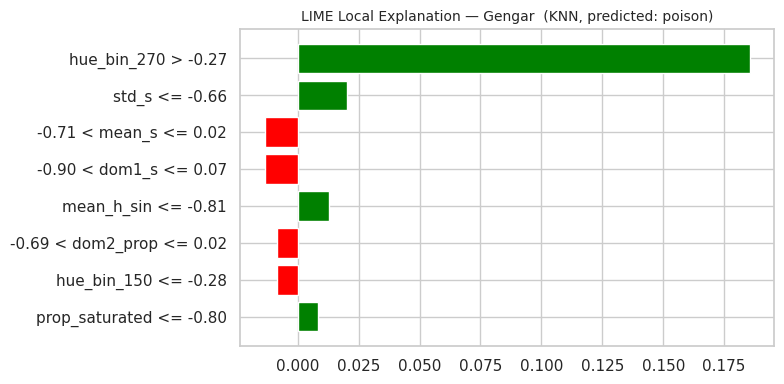


[MISCLASS_WRONG]  Gholdengo  (#1000)
  True type  : steel
  Predicted  : electric  ✗
  Type 2     : ghost


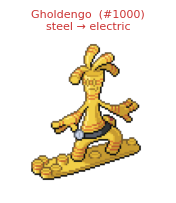


  3 Nearest Neighbours (scaled, pruned feature space):
  Name                   Type1        Type2           Dist
  ---------------------------------------------------------
  Solrock                rock         psychic        4.397
  Paras                  bug          grass          5.829
  Torchic                fire         —              5.837


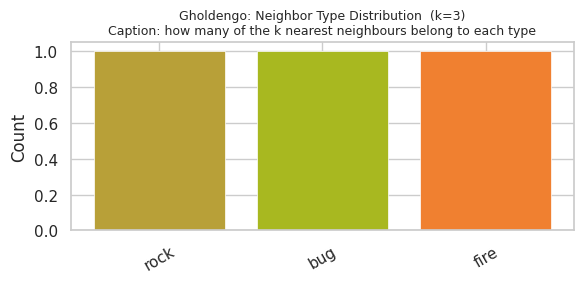

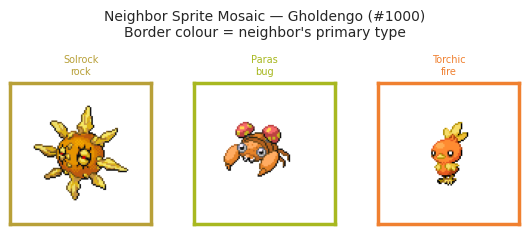

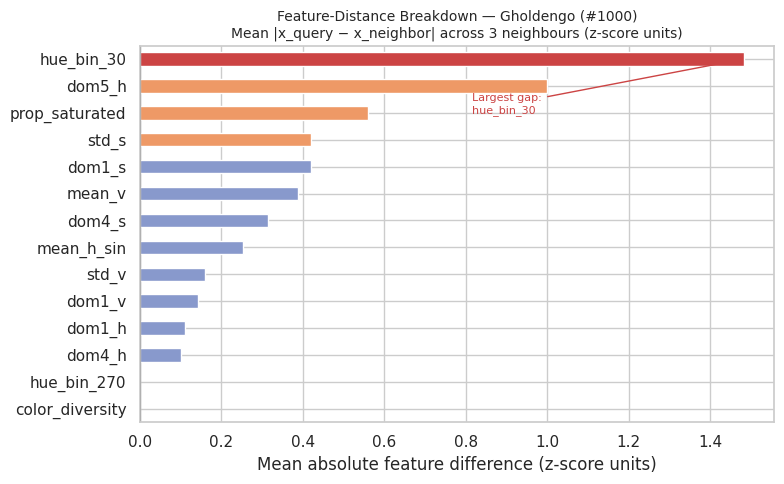

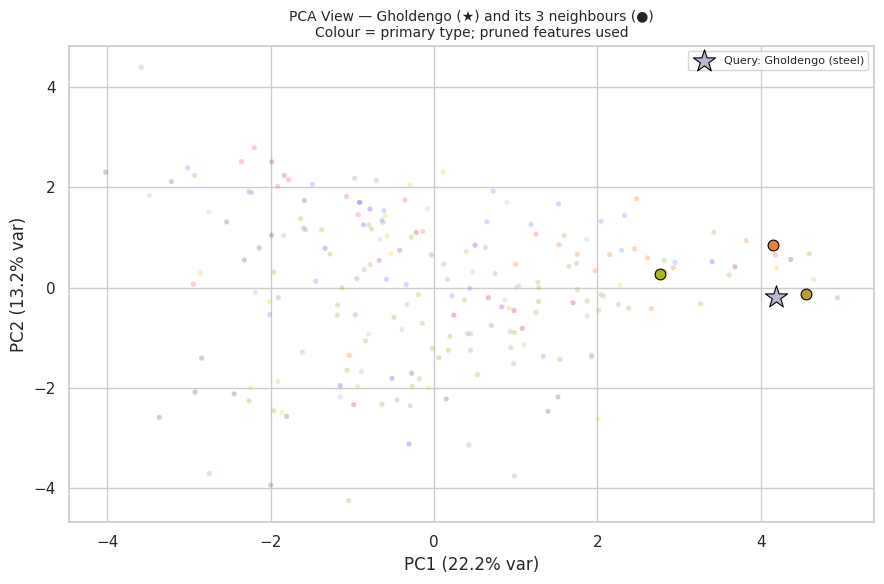

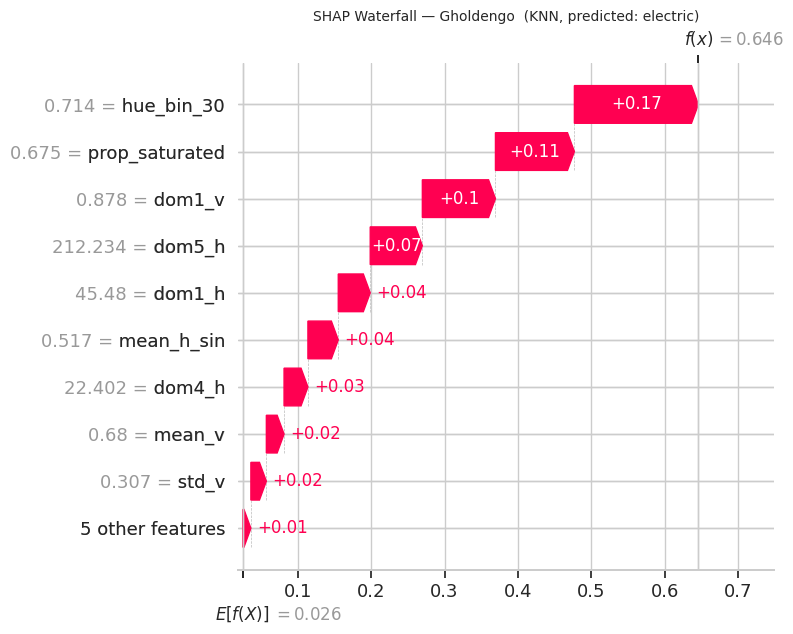

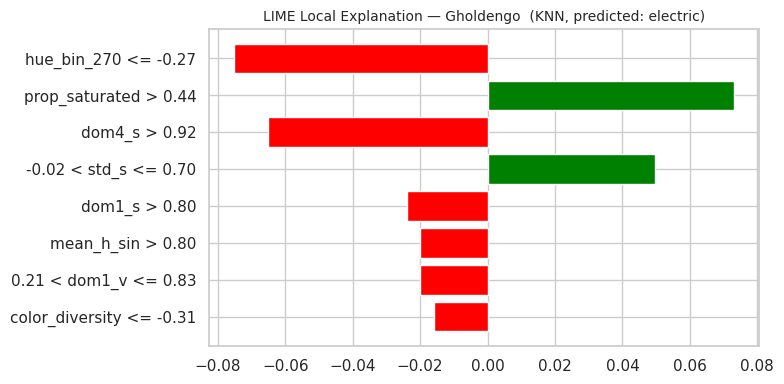

In [210]:
def explain_instance_knn(pokemon_id: int, label: str) -> None:
    """Full local explanation for one Pokémon instance:
    sprite | neighbor mosaic | feature-distance breakdown | SHAP waterfall | LIME.

    Uses knn_explain (real training data, no SMOTE) for neighbor lookup so that
    every neighbor is a real, displayable Pokémon.
    """
    # ── Locate row ───────────────────────────────────────────────────────────
    row_mask = df["id"] == pokemon_id
    if not row_mask.any():
        print(f"ID {pokemon_id} not found in dataframe."); return

    row        = df[row_mask].iloc[0]
    df_pos     = df[row_mask].index[0]
    test_indices = split_idx["test_idx"]
    match      = np.where(test_indices == np.where(df.index == df_pos)[0][0])[0]
    if len(match) == 0:
        print(f"Pokémon {pokemon_id} ({row['name']}) is in the TRAINING set — "
              "choose a test-set instance."); return

    i           = match[0]
    x_full      = X_test_scaled.iloc[i]          # 42-dim (for LIME)
    x_explain   = X_test_explain.iloc[i]         # 14-dim scaled (for kneighbors)

    # Use predictions from the FINAL pipeline (not the baseline)
    pred_int    = int(y_pred_final[i])
    pred_label  = int_to_type[pred_int]
    true_label  = int_to_type[int(y_test.iloc[i])]
    type2_label = row["type2"] if pd.notna(row["type2"]) else "N/A"

    # ── Header ──────────────────────────────────────────────────────────────
    print(f"\n{'='*65}")
    print(f"[{label.upper()}]  {row['name'].capitalize()}  (#{pokemon_id})")
    print(f"  True type  : {true_label}")
    print(f"  Predicted  : {pred_label}  {'✓' if pred_label == true_label else '✗'}")
    print(f"  Type 2     : {type2_label}")
    if type2_label != "N/A" and pred_label == type2_label:
        print(f"  ★ Predicted type matches secondary type — "
              "classic color-confusion case!")
    print(f"{'='*65}")

    # ── 1. Query sprite ─────────────────────────────────────────────────────
    sprite_path = common.get_sprite_path(pokemon_id)
    if sprite_path.exists():
        fig, ax = plt.subplots(figsize=(2.2, 2.2))
        ax.imshow(Image.open(sprite_path).convert("RGBA"))
        ax.axis("off")
        correct = pred_label == true_label
        title_color = "#2a9d2a" if correct else "#cc3333"
        ax.set_title(
            f"{row['name'].capitalize()}  (#{pokemon_id})\n"
            f"{true_label} → {pred_label}",
            fontsize=8, color=title_color
        )
        plt.tight_layout(); plt.show()

    # ── 2. k nearest neighbours — text table ────────────────────────────────
    k_n = knn_explain.n_neighbors
    distances, neighbor_indices = knn_explain.kneighbors(
        x_explain.values.reshape(1, -1), n_neighbors=k_n
    )
    neighbor_df_indices = X_train_explain.index[neighbor_indices[0]]

    print(f"\n  {k_n} Nearest Neighbours (scaled, pruned feature space):")
    print(f"  {'Name':<22} {'Type1':<12} {'Type2':<12} {'Dist':>7}")
    print(f"  {'-'*57}")
    for ni, dist in zip(neighbor_df_indices, distances[0]):
        nb = df.loc[ni]
        t2 = nb["type2"] if pd.notna(nb["type2"]) else "—"
        print(f"  {nb['name'].capitalize():<22} {nb['type1']:<12} {t2:<12} {dist:>7.3f}")

    # ── 3. Neighbor type distribution ────────────────────────────────────────
    neighbor_types = [df.loc[ni]["type1"] for ni in neighbor_df_indices]
    type_counts    = pd.Series(neighbor_types).value_counts()
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(type_counts.index, type_counts.values,
           color=[common.TYPE_COLORS.get(t, "#888") for t in type_counts.index],
           edgecolor="white", linewidth=0.5)
    ax.set_title(
        f"{row['name'].capitalize()}: Neighbor Type Distribution  (k={k_n})\n"
        "Caption: how many of the k nearest neighbours belong to each type",
        fontsize=9
    )
    ax.set_ylabel("Count"); ax.tick_params(axis="x", rotation=30)
    plt.tight_layout(); plt.show()

    # ── 4. Neighbor sprite mosaic ────────────────────────────────────────────
    n_cols = min(k_n, 5)
    n_rows = (k_n + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 1.9, n_rows * 2.3),
                             squeeze=False)
    axes_flat = axes.reshape(-1)
    for ax_i, ni in enumerate(neighbor_df_indices):
        nb        = df.loc[ni]
        nb_sprite = common.get_sprite_path(int(nb["id"]))
        ax        = axes_flat[ax_i]
        if nb_sprite.exists():
            img = Image.open(nb_sprite).convert("RGBA")
            bg  = Image.new("RGBA", img.size, (255, 255, 255, 255))
            bg.paste(img, mask=img.split()[3])
            ax.imshow(bg)
        else:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                    transform=ax.transAxes, fontsize=8)
        type_color = common.TYPE_COLORS.get(nb["type1"], "#888888")
        for spine in ax.spines.values():
            spine.set_edgecolor(type_color); spine.set_linewidth(2.5)
        ax.set_title(f"{nb['name'].capitalize()}\n{nb['type1']}",
                     fontsize=7, color=type_color)
        ax.set_xticks([]); ax.set_yticks([])
    for ax_i in range(len(neighbor_df_indices), len(axes_flat)):
        axes_flat[ax_i].axis("off")
    fig.suptitle(
        f"Neighbor Sprite Mosaic — {row['name'].capitalize()} (#{pokemon_id})\n"
        f"Border colour = neighbor's primary type",
        fontsize=10, y=1.01
    )
    plt.tight_layout(); plt.show()

    # ── 5. Per-feature distance breakdown (pruned features only) ──────────────
    neighbor_features = X_train_explain.loc[neighbor_df_indices]
    abs_diffs         = (neighbor_features - x_explain.values).abs()
    mean_abs_diff     = abs_diffs.mean(axis=0).nlargest(min(15, len(features_positivas))).sort_values()
    bar_colors_fd     = [
        "#cc4444" if v == mean_abs_diff.max() else
        "#ee9966" if v >= mean_abs_diff.quantile(0.75) else
        "#8899cc"
        for v in mean_abs_diff.values
    ]
    fig, ax = plt.subplots(figsize=(8, 5))
    mean_abs_diff.plot.barh(ax=ax, color=bar_colors_fd)
    ax.set_title(
        f"Feature-Distance Breakdown — {row['name'].capitalize()} (#{pokemon_id})\n"
        f"Mean |x_query − x_neighbor| across {k_n} neighbours (z-score units)",
        fontsize=10
    )
    ax.set_xlabel("Mean absolute feature difference (z-score units)")
    ax.axvline(0, color="black", linewidth=0.8)
    top_feat = mean_abs_diff.index[-1]
    top_val  = mean_abs_diff.iloc[-1]
    ax.annotate(
        f"Largest gap:\n{top_feat}",
        xy=(top_val, len(mean_abs_diff) - 1),
        xytext=(top_val * 0.55, max(0, len(mean_abs_diff) - 3)),
        arrowprops=dict(arrowstyle="->", color="#cc4444"),
        fontsize=8, color="#cc4444"
    )
    plt.tight_layout(); plt.show()

    # ── 6. PCA scatter: query + neighbours highlighted ────────────────────────
    pca2      = PCA(n_components=2, random_state=42)
    X_all_exp = pd.concat([X_train_explain, X_test_explain])
    X_pca_all = pca2.fit_transform(X_all_exp)
    n_train   = len(X_train_explain)
    X_pca_test = X_pca_all[n_train:]

    fig, ax = plt.subplots(figsize=(9, 6))
    for type_name in df["type1"].unique():
        test_mask = (y_test.map(int_to_type) == type_name).values
        if test_mask.sum() == 0:
            continue
        color = common.TYPE_COLORS.get(type_name, "#888888")
        ax.scatter(X_pca_test[test_mask, 0], X_pca_test[test_mask, 1],
                   c=color, alpha=0.3, s=14, edgecolors="none")

    query_pca = X_pca_test[i]
    ax.scatter(*query_pca, marker="*", s=280,
               c=common.TYPE_COLORS.get(true_label, "#000"),
               edgecolors="black", linewidths=0.8, zorder=5,
               label=f"Query: {row['name'].capitalize()} ({true_label})")

    for ni in neighbor_df_indices:
        nb_pos   = X_train_explain.index.get_loc(ni)
        nb_pca   = X_pca_all[nb_pos]
        nb_type  = df.loc[ni, "type1"]
        ax.scatter(*nb_pca, marker="o", s=60,
                   c=common.TYPE_COLORS.get(nb_type, "#888"),
                   edgecolors="black", linewidths=0.8, zorder=4)

    ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)")
    ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)")
    ax.set_title(
        f"PCA View — {row['name'].capitalize()} (★) and its {k_n} neighbours (●)\n"
        "Colour = primary type; pruned features used",
        fontsize=10
    )
    ax.legend(fontsize=8, loc="upper right")
    plt.tight_layout(); plt.show()

    # ── 7. SHAP waterfall ────────────────────────────────────────────────────
    shap_idx_in_sample = np.where(shap_sample_idx == i)[0]
    if len(shap_idx_in_sample) > 0:
        sample_i = shap_idx_in_sample[0]
        clases   = pipeline_final.named_steps["knn"].classes_
        pred_pos = list(clases).index(pred_int)
        sv       = shap_values_knn[sample_i, :, pred_pos]
        base     = kernel_explainer.expected_value[pred_pos]
        exp_obj  = shap.Explanation(
            values        = sv,
            base_values   = base,
            data          = X_test_shap.iloc[sample_i].values,
            feature_names = features_positivas
        )
        plt.figure(figsize=(10, 5))
        shap.plots.waterfall(exp_obj, show=False)
        plt.title(
            f"SHAP Waterfall — {row['name'].capitalize()}  "
            f"(KNN, predicted: {pred_label})",
            fontsize=10
        )
        plt.tight_layout(); plt.show()
    else:
        print("  [SHAP] Instance not in pre-computed sample — skipping waterfall.\n"
              "  Re-run the SHAP cell with this index added to shap_sample_idx.")

    # ── 8. LIME ──────────────────────────────────────────────────────────────
    def _predict_proba_for_lime(X_array: np.ndarray) -> np.ndarray:
        X_df    = pd.DataFrame(X_array, columns=X_train.columns)
        X_clean = X_df[features_positivas]
        return pipeline_final.predict_proba(X_clean)

    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data = X_train_scaled.values,
        feature_names = X_train.columns.tolist(),
        class_names   = [int_to_type[j] for j in sorted(int_to_type)],
        mode          = "classification",
        random_state  = common.RANDOM_STATE,
    )
    lime_exp = lime_explainer.explain_instance(
        x_full.values,
        _predict_proba_for_lime,
        num_features=8,
        top_labels=1,
    )
    lime_label_id = lime_exp.top_labels[0]
    fig = lime_exp.as_pyplot_figure(label=lime_label_id)
    fig.set_size_inches(8, 4)
    plt.title(
        f"LIME Local Explanation — {row['name'].capitalize()}  "
        f"(KNN, predicted: {pred_label})",
        fontsize=10
    )
    plt.tight_layout(); plt.show()


# ── Run all cases ────────────────────────────────────────────────────────────
for case_label, pid in explain_cases.items():
    explain_instance_knn(pid, case_label)


The four local explanations above showcase different KNN behaviours:

- **Gyarados (#130, correct_clear):** True type Water, predicted **Fighting**. Despite its blue colour, the 3 nearest neighbours include Zamazenta (Fighting) whose similar colour diversity and saturation pull the vote away from Water. This highlights a limitation of KNN with very few neighbours (k=3): a single atypical neighbour can flip the prediction. The feature-distance breakdown shows which pruned features create the largest gap between Gyarados and its neighbours.

- **Iron Crown (#1023, correct_surprise):** True type Steel, predicted **Bug**. Its nearest neighbour is Cobalion (Steel), but the next two (Surskit and Quaxwell) belong to other types. The blue-green palette of Iron Crown overlaps with several type clusters in the pruned feature space, making it a genuinely ambiguous instance.

- **Gengar (#94, misclass_secondary):** True type Ghost, predicted **Poison** — which is exactly Gengar's secondary type. This is the classic **colour-confusion case**: Gengar's purple palette sits squarely in the Poison colour signature. The neighbour list (Mismagius/Ghost, Nidoran-m/Poison, Muk/Poison) reveals the vote split directly. From an XAI perspective, this misclassification is *informative*: the model is not wrong about the colour, it simply cannot distinguish Ghost-purple from Poison-purple using colour features alone.

- **Gholdengo (#1000, misclass_wrong):** True type Steel, predicted **Electric**. Its golden sprite maps to the yellow–orange hue range (`hue_bin_30`), which is the strongest feature for Electric types. The neighbours (Solrock, Paras, Torchic) span multiple types — none of them Steel — revealing that Gholdengo's colour profile is an outlier within its true class.

Across all four cases, the **neighbour mosaic** provides the most intuitive explanation: a non-technical viewer can immediately see *which Pokémon the model considers similar* and judge whether the comparison makes visual sense. The LIME and SHAP attributions complement this by quantifying *which features* drive the similarity, but the neighbour list remains the most faithful explanation for KNN — it *is* the model's reasoning, not an approximation of it.

## 4. Type Prototypes — Best and Worst Representatives

For each Pokémon type, we identify the **prototype** (the training Pokémon closest to the type centroid in scaled, pruned feature space) and the **outlier** (the one farthest from its centroid).

From an XAI perspective, prototypes are the most "explainable" instances — they embody the typical color signature of their type. Outliers are the hardest to classify: their colors deviate from the type norm, making them the most likely candidates for misclassification and the most interesting cases for local explanation.

In [211]:
# ── Compute type centroids and find closest/farthest Pokémon ─────────────────
from scipy.spatial.distance import cdist

centroids = {}
prototypes = {}  # closest to centroid
outliers = {}    # farthest from centroid

for cls_int in sorted(int_to_type.keys()):
    type_name = int_to_type[cls_int]
    mask = (y_train == cls_int)
    if mask.sum() == 0:
        continue
    X_type = X_train_explain.loc[mask.index[mask]]
    centroid = X_type.mean(axis=0).values
    centroids[type_name] = centroid

    # scipy uses 'cityblock' instead of sklearn's 'manhattan'
    scipy_metric = 'cityblock' if mejor_metric == 'manhattan' else mejor_metric
    dists = cdist(X_type.values, centroid.reshape(1, -1), metric=scipy_metric).ravel()
    proto_idx = X_type.index[np.argmin(dists)]
    outl_idx  = X_type.index[np.argmax(dists)]

    prototypes[type_name] = {
        "df_idx": proto_idx,
        "id": int(df.loc[proto_idx, "id"]),
        "name": df.loc[proto_idx, "name"],
        "dist": dists.min(),
    }
    outliers[type_name] = {
        "df_idx": outl_idx,
        "id": int(df.loc[outl_idx, "id"]),
        "name": df.loc[outl_idx, "name"],
        "dist": dists.max(),
    }

# ── Print summary table ─────────────────────────────────────────────────────
print(f"{'Type':<12} {'Prototype':<22} {'Dist':>6}    {'Outlier':<22} {'Dist':>6}")
print("-" * 75)
for type_name in sorted(prototypes.keys()):
    p = prototypes[type_name]
    o = outliers[type_name]
    print(f"{type_name:<12} {p['name'].capitalize():<22} {p['dist']:>6.2f}    "
          f"{o['name'].capitalize():<22} {o['dist']:>6.2f}")


Type         Prototype                Dist    Outlier                  Dist
---------------------------------------------------------------------------
bug          Wurmple                  7.35    Venomoth                19.12
dark         Honchkrow                6.85    Scrafty                 19.18
dragon       Shelgon                  6.27    Zekrom                  18.98
electric     Manectric                7.25    Toxel                   20.73
fairy        Snubbull                 4.66    Milcery                 15.31
fighting     Machamp                  6.42    Makuhita                14.53
fire         Magmortar                5.85    Emboar                  15.94
ghost        Shuppet                  8.32    Cursola                 27.29
grass        Thwackey                 4.22    Shroomish               14.47
ground       Flygon                   6.65    Sandslash               16.31
ice          Eiscue-ice               5.86    Smoochum                15.18
normal      

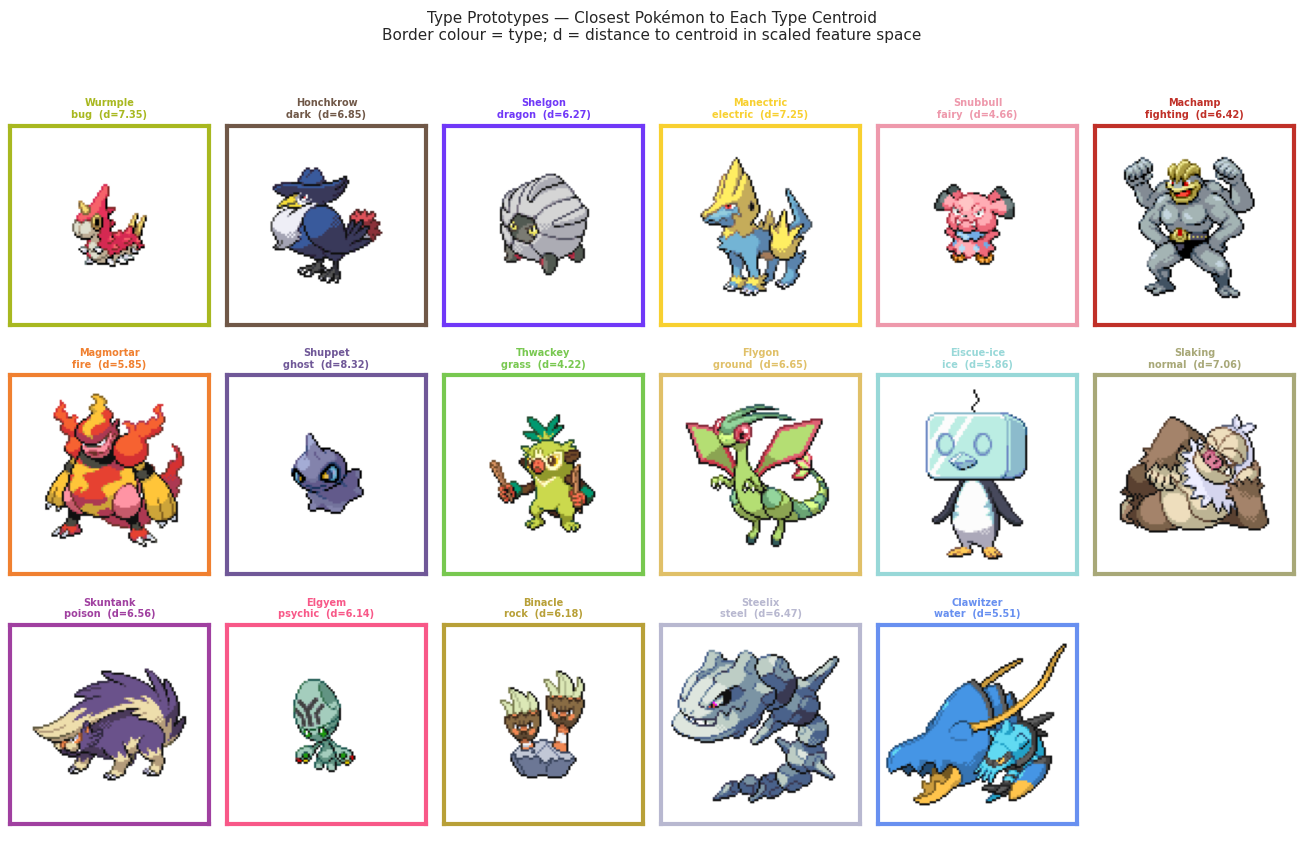

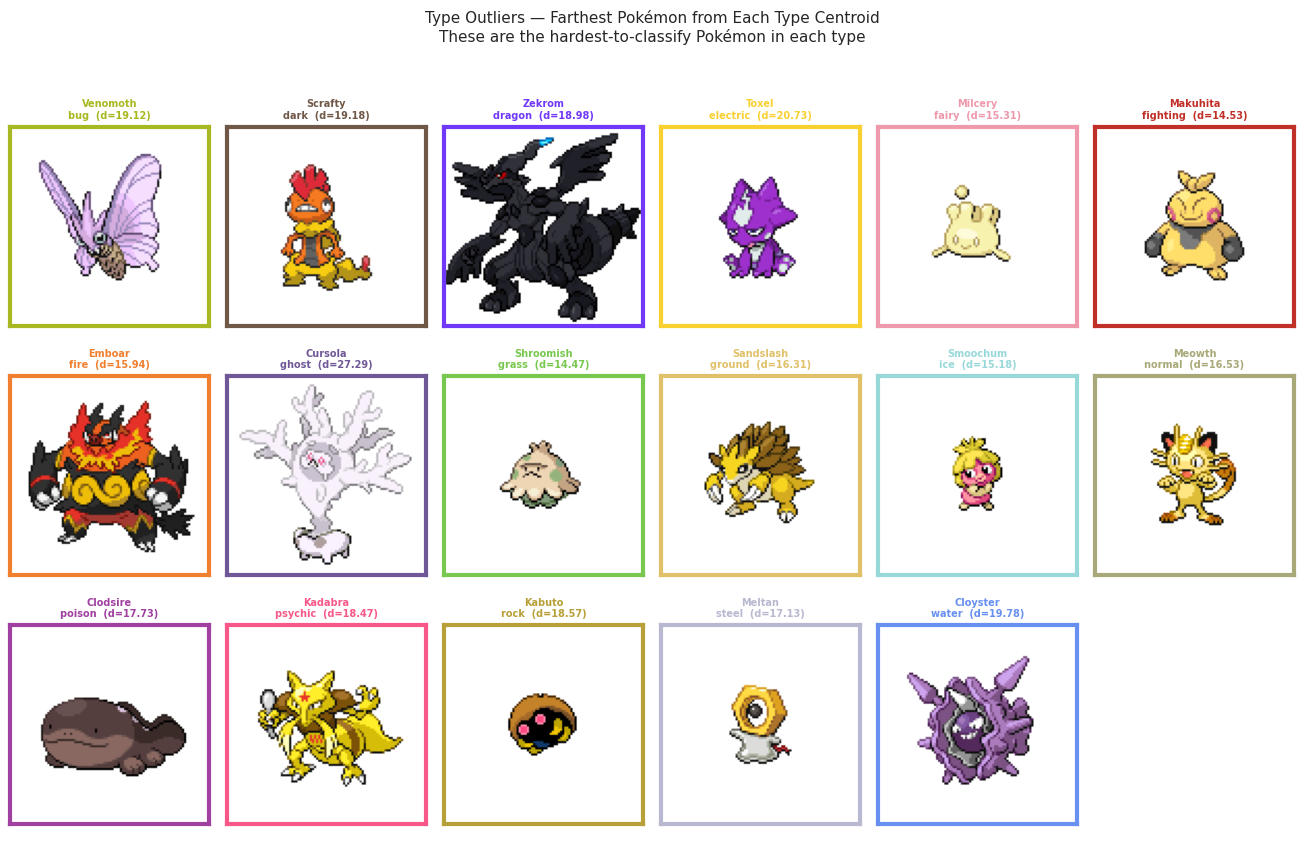

In [212]:
# ── Prototype sprite mosaic ──────────────────────────────────────────────────
sorted_types = sorted(prototypes.keys())
n_types = len(sorted_types)
n_cols = min(6, n_types)
n_rows = (n_types + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 2.2, n_rows * 2.8),
                         squeeze=False)
axes_flat = axes.reshape(-1)

for ax_i, type_name in enumerate(sorted_types):
    p = prototypes[type_name]
    sprite_path = common.get_sprite_path(p["id"])
    ax = axes_flat[ax_i]
    if sprite_path.exists():
        img = Image.open(sprite_path).convert("RGBA")
        bg  = Image.new("RGBA", img.size, (255, 255, 255, 255))
        bg.paste(img, mask=img.split()[3])
        ax.imshow(bg)
    else:
        ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                transform=ax.transAxes, fontsize=8)
    type_color = common.TYPE_COLORS.get(type_name, "#888888")
    for spine in ax.spines.values():
        spine.set_edgecolor(type_color); spine.set_linewidth(3)
    ax.set_title(f"{p['name'].capitalize()}\n{type_name}  (d={p['dist']:.2f})",
                 fontsize=7, color=type_color, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])

for ax_i in range(n_types, len(axes_flat)):
    axes_flat[ax_i].axis("off")

fig.suptitle("Type Prototypes — Closest Pokémon to Each Type Centroid\n"
             "Border colour = type; d = distance to centroid in scaled feature space",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# ── Outlier sprite mosaic ────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(n_rows, n_cols,
                           figsize=(n_cols * 2.2, n_rows * 2.8),
                           squeeze=False)
axes_flat2 = axes2.reshape(-1)

for ax_i, type_name in enumerate(sorted_types):
    o = outliers[type_name]
    sprite_path = common.get_sprite_path(o["id"])
    ax = axes_flat2[ax_i]
    if sprite_path.exists():
        img = Image.open(sprite_path).convert("RGBA")
        bg  = Image.new("RGBA", img.size, (255, 255, 255, 255))
        bg.paste(img, mask=img.split()[3])
        ax.imshow(bg)
    else:
        ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                transform=ax.transAxes, fontsize=8)
    type_color = common.TYPE_COLORS.get(type_name, "#888888")
    for spine in ax.spines.values():
        spine.set_edgecolor(type_color); spine.set_linewidth(3)
    ax.set_title(f"{o['name'].capitalize()}\n{type_name}  (d={o['dist']:.2f})",
                 fontsize=7, color=type_color, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])

for ax_i in range(n_types, len(axes_flat2)):
    axes_flat2[ax_i].axis("off")

fig2.suptitle("Type Outliers — Farthest Pokémon from Each Type Centroid\n"
              "These are the hardest-to-classify Pokémon in each type",
              fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


The prototype mosaic visually confirms the model's feature-space intuitions:

- **Fire prototype** should display a strongly red/orange sprite — the "most Fire-looking" Fire Pokémon.
- **Water prototype** should be distinctly blue, with high saturation.
- **Dark/Ghost outliers** are often Pokémon with unexpectedly bright or colourful sprites for their type — the ones that "don't look the part."

This analysis bridges global and local explainability: the prototypes represent the **centroid** of each type's color distribution (a global property), while each individual prototype or outlier can be further investigated with the local explanation function above to understand *which specific features* make it typical or atypical.